# 一、載入套件及資料集

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
import os

def setup_chinese_font():
    """設定 matplotlib 中文字體顯示"""
    system = platform.system()
    
    if system == 'Windows':  # Windows 系統
        font_candidates = [ 'Microsoft YaHei', 'SimHei', 'Arial Unicode MS' ]
    elif system == 'Darwin':  # macOS
        font_candidates = [ 'Arial Unicode MS', 'Heiti TC', 'STHeiti' ]
    else:  # Linux
        font_candidates = [ 'Noto Sans CJK JP' ]
    
    # 測試字體是否可用
    import matplotlib.font_manager as fm
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in font_candidates:
        if font in available_fonts:
            plt.rcParams['font.sans-serif'] = [font]
            # print(f"✅ 使用字體: {font}")
            break
    else:
        # print("⚠️  未找到合適的中文字體，使用預設字體")
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    
    # 解決負號顯示問題
    plt.rcParams['axes.unicode_minus'] = False
    
    # # 設定字體大小和樣式
    # plt.rcParams['font.size'] = 10
    # plt.rcParams['axes.titlesize'] = 12
    # plt.rcParams['axes.labelsize'] = 11
    # plt.rcParams['xtick.labelsize'] = 9
    # plt.rcParams['ytick.labelsize'] = 9
    # plt.rcParams['legend.fontsize'] = 9

# 設定中文字體
setup_chinese_font()

# === 讀取資料 ===
rawData = pd.read_csv('../Urban_Air_Quality_and_Health_Impact_Dataset.csv')
rawData.info()
rawData.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           1000 non-null   object 
 1   datetimeEpoch      1000 non-null   float64
 2   tempmax            1000 non-null   float64
 3   tempmin            1000 non-null   float64
 4   temp               1000 non-null   float64
 5   feelslikemax       1000 non-null   float64
 6   feelslikemin       1000 non-null   float64
 7   feelslike          1000 non-null   float64
 8   dew                1000 non-null   float64
 9   humidity           1000 non-null   float64
 10  precip             1000 non-null   float64
 11  precipprob         1000 non-null   float64
 12  precipcover        1000 non-null   float64
 13  preciptype         378 non-null    object 
 14  snow               1000 non-null   float64
 15  snowdepth          929 non-null    float64
 16  windgust           1000 n

(1000, 46)

# 缺失值處理

📊 資料集基本資訊
資料筆數: 1,000
欄位數量: 46
資料大小: 0.90 MB

🔍 缺失值分析

⚠️  發現 4 個欄位有缺失值：

          欄位名稱  缺失數量  缺失比例(%)    資料型別
      stations   933     93.3  object
    preciptype   622     62.2  object
Condition_Code   431     43.1 float64
     snowdepth    71      7.1 float64

--------------------------------------------------------------------------------
📈 缺失值統計摘要：
   • 總缺失值數量: 2,057
   • 平均缺失比例: 51.42%
   • 最高缺失比例: 93.30% (stations)

--------------------------------------------------------------------------------
🎯 缺失值嚴重程度分類：

   🔴 嚴重缺失 (>50%): 2 個欄位
      → stations, preciptype
      建議: 考慮刪除這些欄位或僅作為參考

   🟡 中度缺失 (10-50%): 1 個欄位
      → Condition_Code
      建議: 謹慎處理，可考慮插補或標記缺失

   🟢 輕微缺失 (<10%): 1 個欄位
      → snowdepth
      建議: 可用均值/中位數/眾數插補

📋 完整欄位列表及資料型別：
             欄位名稱    資料型別  缺失數量
         datetime  object     0
    datetimeEpoch float64     0
          tempmax float64     0
          tempmin float64     0
             temp float64     0
     feelslikemax float64     0
     feelslikemi

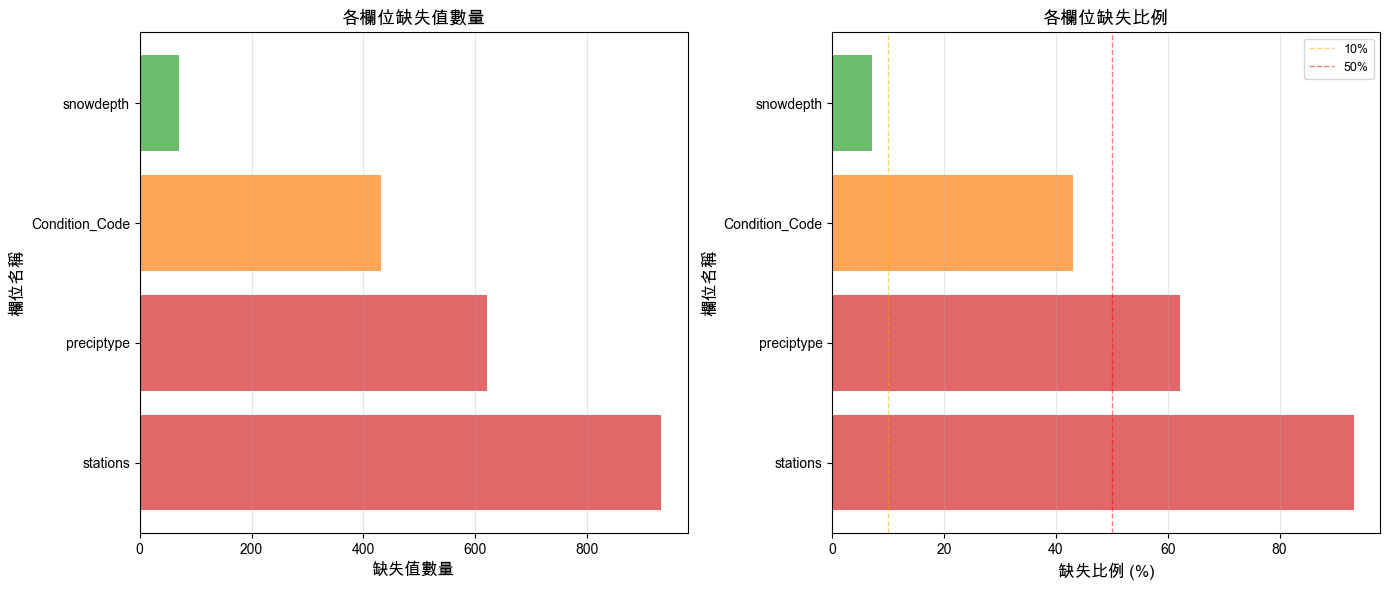


💡 缺失值處理建議：
1. 刪除欄位: 缺失比例 > 50% 的欄位，資訊價值較低
2. 刪除列: 若某些觀測值缺失過多欄位，可考慮刪除該列
3. 數值型插補: 使用均值(mean)、中位數(median)或前後值插補
4. 類別型插補: 使用眾數(mode)或新增'Unknown'類別
5. 進階方法: KNN插補、迴歸插補、多重插補(MICE)
6. 標記缺失: 新增二元欄位標記是否為缺失值，保留缺失模式資訊


In [63]:
# 缺失值分析與統計
print("=" * 80)
print("📊 資料集基本資訊")
print("=" * 80)
print(f"資料筆數: {rawData.shape[0]:,}")
print(f"欄位數量: {rawData.shape[1]}")
print(f"資料大小: {rawData.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 80)
print("🔍 缺失值分析")
print("=" * 80)

# 計算每個欄位的缺失值
missing_stats = pd.DataFrame({
    '欄位名稱': rawData.columns,
    '缺失數量': rawData.isnull().sum().values,
    '缺失比例(%)': (rawData.isnull().sum().values / len(rawData) * 100).round(2),
    '資料型別': rawData.dtypes.values
})

# 只顯示有缺失值的欄位
missing_data = missing_stats[missing_stats['缺失數量'] > 0].sort_values('缺失數量', ascending=False)

if len(missing_data) > 0:
    print(f"\n⚠️  發現 {len(missing_data)} 個欄位有缺失值：\n")
    print(missing_data.to_string(index=False))
    
    print("\n" + "-" * 80)
    print("📈 缺失值統計摘要：")
    print(f"   • 總缺失值數量: {missing_data['缺失數量'].sum():,}")
    print(f"   • 平均缺失比例: {missing_data['缺失比例(%)'].mean():.2f}%")
    print(f"   • 最高缺失比例: {missing_data['缺失比例(%)'].max():.2f}% ({missing_data.iloc[0]['欄位名稱']})")
    
    # 缺失值嚴重程度分類
    severe = missing_data[missing_data['缺失比例(%)'] > 50]
    moderate = missing_data[(missing_data['缺失比例(%)'] > 10) & (missing_data['缺失比例(%)'] <= 50)]
    minor = missing_data[missing_data['缺失比例(%)'] <= 10]
    
    print("\n" + "-" * 80)
    print("🎯 缺失值嚴重程度分類：")
    if len(severe) > 0:
        print(f"\n   🔴 嚴重缺失 (>50%): {len(severe)} 個欄位")
        print(f"      → {', '.join(severe['欄位名稱'].tolist())}")
        print(f"      建議: 考慮刪除這些欄位或僅作為參考")
    
    if len(moderate) > 0:
        print(f"\n   🟡 中度缺失 (10-50%): {len(moderate)} 個欄位")
        print(f"      → {', '.join(moderate['欄位名稱'].tolist())}")
        print(f"      建議: 謹慎處理，可考慮插補或標記缺失")
    
    if len(minor) > 0:
        print(f"\n   🟢 輕微缺失 (<10%): {len(minor)} 個欄位")
        print(f"      → {', '.join(minor['欄位名稱'].tolist())}")
        print(f"      建議: 可用均值/中位數/眾數插補")
    
else:
    print("\n✅ 太好了！資料集中沒有任何缺失值。")

# 顯示完整欄位列表
print("\n" + "=" * 80)
print("📋 完整欄位列表及資料型別：")
print("=" * 80)
print(missing_stats[['欄位名稱', '資料型別', '缺失數量']].to_string(index=False))

# 視覺化缺失值分佈
if len(missing_data) > 0:
    
    
    plt.figure(figsize=(14, 6))
    
    # 子圖1: 缺失值數量長條圖
    plt.subplot(1, 2, 1)
    colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 10 else '#2ca02c' 
              for x in missing_data['缺失比例(%)']]
    plt.barh(missing_data['欄位名稱'], missing_data['缺失數量'], color=colors, alpha=0.7)
    plt.xlabel('缺失值數量', fontsize=12)
    plt.ylabel('欄位名稱', fontsize=12)
    plt.title('各欄位缺失值數量', fontsize=13, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # 子圖2: 缺失比例百分比
    plt.subplot(1, 2, 2)
    plt.barh(missing_data['欄位名稱'], missing_data['缺失比例(%)'], color=colors, alpha=0.7)
    plt.xlabel('缺失比例 (%)', fontsize=12)
    plt.ylabel('欄位名稱', fontsize=12)
    plt.title('各欄位缺失比例', fontsize=13, fontweight='bold')
    plt.axvline(x=10, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='10%')
    plt.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50%')
    plt.legend(fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 80)
    print("💡 缺失值處理建議：")
    print("=" * 80)
    print("1. 刪除欄位: 缺失比例 > 50% 的欄位，資訊價值較低")
    print("2. 刪除列: 若某些觀測值缺失過多欄位，可考慮刪除該列")
    print("3. 數值型插補: 使用均值(mean)、中位數(median)或前後值插補")
    print("4. 類別型插補: 使用眾數(mode)或新增'Unknown'類別")
    print("5. 進階方法: KNN插補、迴歸插補、多重插補(MICE)")
    print("6. 標記缺失: 新增二元欄位標記是否為缺失值，保留缺失模式資訊")
else:
    print("\n✨ 資料品質優良，可直接進行後續分析！")

In [64]:
# 缺失值處理 - 刪除無用的缺失值欄位

# 確認要刪除的欄位
columns_to_drop = ['stations', 'preciptype', 'Condition_Code', 'snowdepth']

print("=" * 80)
print("🗑️  刪除無用的缺失值欄位")
print("=" * 80)

# 顯示刪除前的資料形狀
print(f"\n刪除前:")
print(f"   • 資料筆數: {rawData.shape[0]:,}")
print(f"   • 欄位數量: {rawData.shape[1]}")

# 檢查欄位是否存在並顯示資訊
print(f"\n準備刪除的欄位:")
for col in columns_to_drop:
    if col in rawData.columns:
        missing_count = rawData[col].isna().sum()
        missing_pct = (missing_count / len(rawData) * 100)
        print(f"   ✓ {col:<20} - 缺失值: {missing_count:,} ({missing_pct:.2f}%)")
    else:
        print(f"   ✗ {col:<20} - 欄位不存在")

# 刪除欄位
existing_columns = [col for col in columns_to_drop if col in rawData.columns]
rawData = rawData.drop(columns=existing_columns)

print(f"\n刪除後:")
print(f"   • 資料筆數: {rawData.shape[0]:,}")
print(f"   • 欄位數量: {rawData.shape[1]}")
print(f"   • 已刪除欄位數: {len(existing_columns)}")

# 確認是否還有其他缺失值
remaining_missing = rawData.isnull().sum().sum()
if remaining_missing > 0:
    print(f"\n⚠️  資料集中仍有 {remaining_missing:,} 個缺失值需要處理")
    missing_cols = rawData.columns[rawData.isnull().any()].tolist()
    print(f"   有缺失值的欄位: {', '.join(missing_cols)}")
else:
    print(f"\n✅ 資料集中已無任何缺失值！")

print("\n" + "=" * 80)



🗑️  刪除無用的缺失值欄位

刪除前:
   • 資料筆數: 1,000
   • 欄位數量: 46

準備刪除的欄位:
   ✓ stations             - 缺失值: 933 (93.30%)
   ✓ preciptype           - 缺失值: 622 (62.20%)
   ✓ Condition_Code       - 缺失值: 431 (43.10%)
   ✓ snowdepth            - 缺失值: 71 (7.10%)

刪除後:
   • 資料筆數: 1,000
   • 欄位數量: 42
   • 已刪除欄位數: 4

✅ 資料集中已無任何缺失值！



# 重複值與類似特徵處理

In [65]:
# 重複值與類似特徵處理

print("=" * 80)
print("🔍 檢查重複資料與相似特徵")
print("=" * 80)

# 1. 檢查並移除完全重複的資料列
print("\n" + "=" * 80)
print("1️⃣  檢查完全重複的資料列")
print("=" * 80)

duplicate_count = rawData.duplicated().sum()
print(f"完全重複的資料筆數: {duplicate_count:,}")

if duplicate_count > 0:
    print(f"⚠️  發現 {duplicate_count:,} 筆完全重複的資料，準備移除...")
    
    # 顯示重複資料的範例
    duplicate_rows = rawData[rawData.duplicated(keep=False)]
    print(f"\n重複資料範例 (前5筆):")
    print(duplicate_rows.head().to_string())
    
    before_count = len(rawData)
    rawData = rawData.drop_duplicates()
    after_count = len(rawData)
    print(f"\n✅ 已移除 {before_count - after_count:,} 筆重複資料")
    print(f"   剩餘資料筆數: {after_count:,}")
else:
    print("✅ 沒有發現完全重複的資料")

# 2. 檢查重複或高度相似的特徵欄位
print("\n" + "=" * 80)
print("2️⃣  檢查重複或高度相似的特徵欄位")
print("=" * 80)

# 2.1 檢查完全相同的欄位（數值型）
print("\n📊 檢查完全相同的數值型欄位:")
numeric_cols = rawData.select_dtypes(include=[np.number]).columns.tolist()
duplicate_columns = []

for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        col1, col2 = numeric_cols[i], numeric_cols[j]
        if rawData[col1].equals(rawData[col2]):
            duplicate_columns.append((col1, col2))
            print(f"   ⚠️  {col1} 與 {col2} 完全相同")

if not duplicate_columns:
    print("   ✅ 未發現完全相同的數值型欄位")

# 2.2 檢查高度相關的特徵（相關係數 > 0.95）
print("\n📈 檢查高度相關的數值型欄位 (相關係數 > 0.95):")

if len(numeric_cols) > 1:
    # 計算相關係數矩陣
    correlation_matrix = rawData[numeric_cols].corr().abs()
    
    # 找出高度相關的欄位對
    high_correlation_pairs = []
    
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            if correlation_matrix.iloc[i, j] > 0.95:
                col1 = correlation_matrix.columns[i]
                col2 = correlation_matrix.columns[j]
                corr_value = correlation_matrix.iloc[i, j]
                high_correlation_pairs.append({
                    '欄位1': col1,
                    '欄位2': col2,
                    '相關係數': round(corr_value, 4)
                })
    
    if high_correlation_pairs:
        high_corr_df = pd.DataFrame(high_correlation_pairs)
        print(f"\n   發現 {len(high_correlation_pairs)} 組高度相關的欄位對:\n")
        print(high_corr_df.to_string(index=False))
        
        print("\n   💡 建議:")
        print("      • 這些欄位對高度相關，可能包含相似資訊")
        print("      • 建議保留其中一個欄位，移除另一個以避免多重共線性")
        print("      • 或使用 PCA 等降維方法")
    else:
        print("   ✅ 未發現高度相關 (>0.95) 的欄位對")

# 2.3 檢查中度相關的特徵（0.8 < 相關係數 <= 0.95）
print("\n📊 檢查中度相關的數值型欄位 (0.8 < 相關係數 <= 0.95):")

if len(numeric_cols) > 1:
    moderate_correlation_pairs = []
    
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if 0.8 < corr_val <= 0.95:
                col1 = correlation_matrix.columns[i]
                col2 = correlation_matrix.columns[j]
                moderate_correlation_pairs.append({
                    '欄位1': col1,
                    '欄位2': col2,
                    '相關係數': round(corr_val, 4)
                })
    
    if moderate_correlation_pairs:
        moderate_corr_df = pd.DataFrame(moderate_correlation_pairs)
        print(f"\n   發現 {len(moderate_correlation_pairs)} 組中度相關的欄位對:\n")
        # 只顯示前10組
        print(moderate_corr_df.head(10).to_string(index=False))
        if len(moderate_correlation_pairs) > 10:
            print(f"\n   ... 還有 {len(moderate_correlation_pairs) - 10} 組 (省略顯示)")
        
        print("\n   💡 建議:")
        print("      • 這些欄位對有中度相關性")
        print("      • 可考慮保留，但需注意可能的多重共線性問題")
    else:
        print("   ✅ 未發現中度相關 (0.8-0.95) 的欄位對")

# 2.4 檢查類別型欄位的重複
print("\n" + "=" * 80)
print("3️⃣  檢查類別型欄位的相似性")
print("=" * 80)

categorical_cols = rawData.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 1:
    print(f"\n類別型欄位數量: {len(categorical_cols)}")
    
    # 檢查是否有完全相同的類別型欄位
    duplicate_categorical = []
    for i in range(len(categorical_cols)):
        for j in range(i + 1, len(categorical_cols)):
            col1, col2 = categorical_cols[i], categorical_cols[j]
            if rawData[col1].equals(rawData[col2]):
                duplicate_categorical.append((col1, col2))
                print(f"   ⚠️  {col1} 與 {col2} 完全相同")
    
    if not duplicate_categorical:
        print("   ✅ 未發現完全相同的類別型欄位")
    
    # 顯示各類別型欄位的唯一值數量
    print("\n   各類別型欄位的唯一值數量:")
    for col in categorical_cols:
        unique_count = rawData[col].nunique()
        print(f"      • {col}: {unique_count} 個唯一值")
else:
    print(f"類別型欄位數量: {len(categorical_cols)}")
    if len(categorical_cols) == 0:
        print("   ✅ 沒有類別型欄位")

# 4. 總結
print("\n" + "=" * 80)
print("📊 特徵相似性檢查總結")
print("=" * 80)
print(f"✅ 完全重複的資料列: {'已移除' if duplicate_count > 0 else '無'}")
print(f"✅ 完全相同的數值型欄位對: {len(duplicate_columns)} 組")
print(f"✅ 高度相關的欄位對 (>0.95): {len(high_correlation_pairs) if len(numeric_cols) > 1 else 0} 組")
print(f"✅ 中度相關的欄位對 (0.8-0.95): {len(moderate_correlation_pairs) if len(numeric_cols) > 1 else 0} 組")
print(f"✅ 完全相同的類別型欄位對: {len(duplicate_categorical) if len(categorical_cols) > 1 else 0} 組")

print("\n" + "=" * 80)
print("💡 後續建議:")
print("=" * 80)
print("1. 移除完全相同的欄位，保留其中一個即可")
print("2. 對於高度相關的欄位，考慮只保留其中一個或進行 PCA 降維")
print("3. 對於中度相關的欄位，可以保留但需注意模型的多重共線性")
print("4. 使用特徵重要性分析來決定保留哪些相似特徵")
print("\n" + "=" * 80)


🔍 檢查重複資料與相似特徵

1️⃣  檢查完全重複的資料列
完全重複的資料筆數: 0
✅ 沒有發現完全重複的資料

2️⃣  檢查重複或高度相似的特徵欄位

📊 檢查完全相同的數值型欄位:
   ✅ 未發現完全相同的數值型欄位

📈 檢查高度相關的數值型欄位 (相關係數 > 0.95):

   發現 10 組高度相關的欄位對:

           欄位1          欄位2   相關係數
 datetimeEpoch sunriseEpoch 0.9920
 datetimeEpoch  sunsetEpoch 0.9921
 datetimeEpoch    moonphase 0.9905
       tempmax feelslikemax 0.9521
       tempmin feelslikemin 0.9883
          temp    feelslike 0.9765
solarradiation  solarenergy 0.9913
  sunriseEpoch  sunsetEpoch 0.9918
  sunriseEpoch    moonphase 0.9899
   sunsetEpoch    moonphase 0.9899

   💡 建議:
      • 這些欄位對高度相關，可能包含相似資訊
      • 建議保留其中一個欄位，移除另一個以避免多重共線性
      • 或使用 PCA 等降維方法

📊 檢查中度相關的數值型欄位 (0.8 < 相關係數 <= 0.95):

   發現 16 組中度相關的欄位對:

    欄位1          欄位2   相關係數
tempmax      tempmin 0.8084
tempmax         temp 0.9364
tempmax feelslikemin 0.8018
tempmax    feelslike 0.9126
tempmin         temp 0.9443
tempmin feelslikemax 0.8203
tempmin    feelslike 0.9396
   temp feelslikemax 0.9204
   temp feelslikemin 0.9398
   temp   Heat_

# EDA、相關係數分析

📊 探索性資料分析 (EDA) 與相關係數分析

1️⃣  數值型欄位統計摘要

數值型欄位數量: 31

統計摘要 (前10個欄位):
       datetimeEpoch      tempmax      tempmin         temp  feelslikemax  feelslikemin    feelslike          dew     humidity       precip
count   1.000000e+03  1000.000000  1000.000000  1000.000000   1000.000000   1000.000000  1000.000000  1000.000000  1000.000000  1000.000000
mean    1.726284e+09    85.106961    68.641638    76.115967     85.195384     68.547548    76.323286    57.267120    56.782281     0.032135
std     3.745834e+05     9.524231     8.474102     8.722070      9.496951      8.365809     8.621361     9.161517    16.708667     0.083461
min     1.725624e+09    62.035432    49.108218    55.548415     62.206413     48.834041    57.748822    26.261814    11.752135    -0.021213
25%     1.725948e+09    78.661118    62.678245    69.102499     78.485332     62.734961    68.930104    51.229378    49.982029    -0.000511
50%     1.726285e+09    84.322847    67.702405    75.222751     84.284077     67.844544    

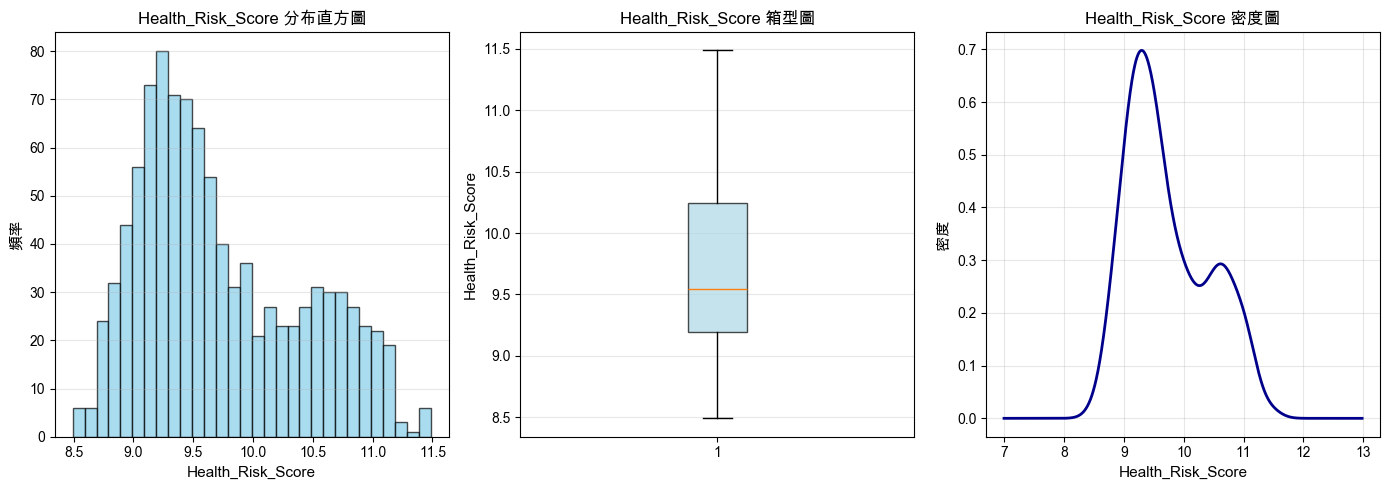


3️⃣  數值型欄位分布分析

顯示前 6 個特徵的分布:


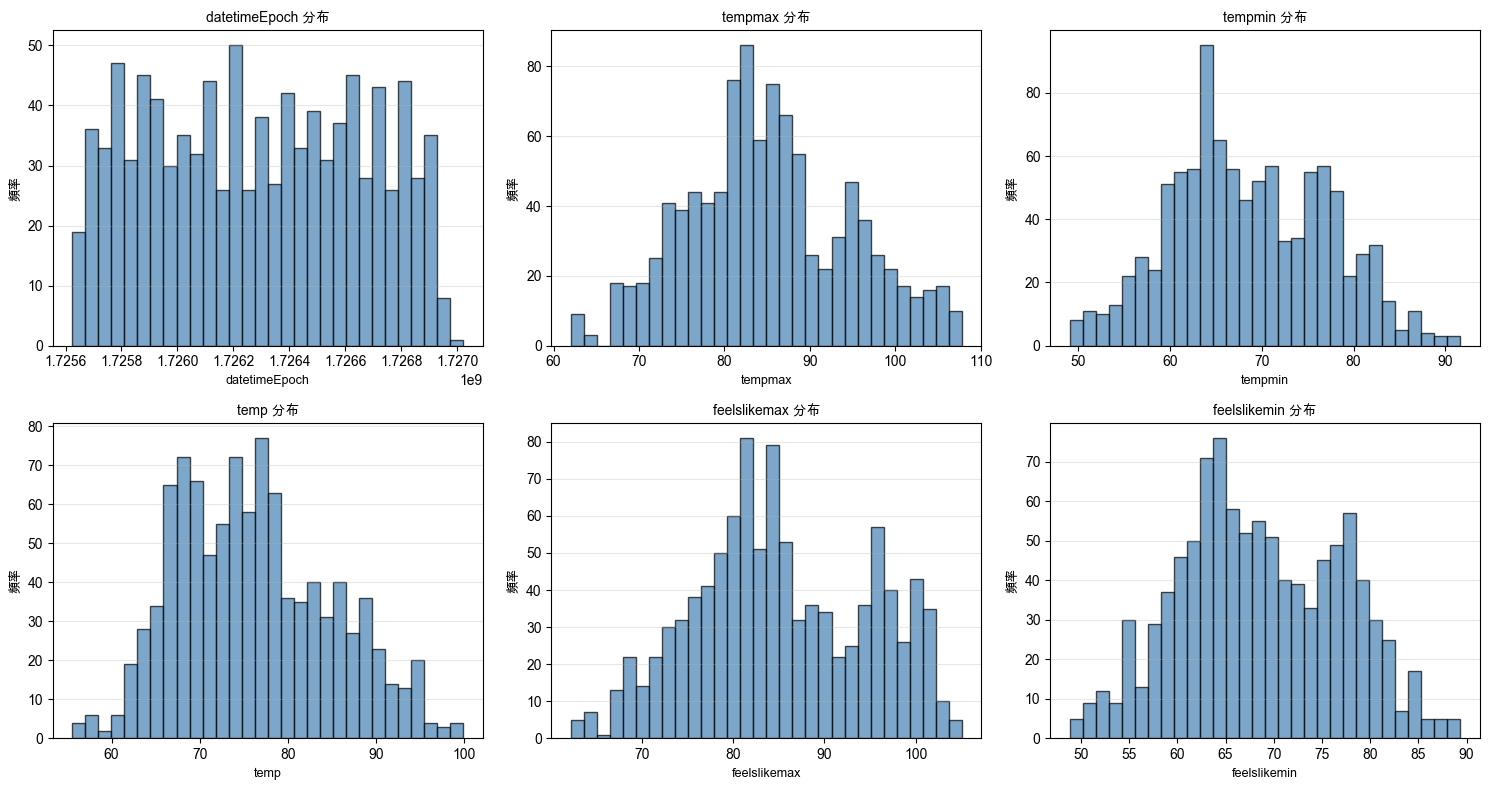


4️⃣  相關係數分析

計算 Pearson 相關係數矩陣...

繪製相關係數熱力圖...


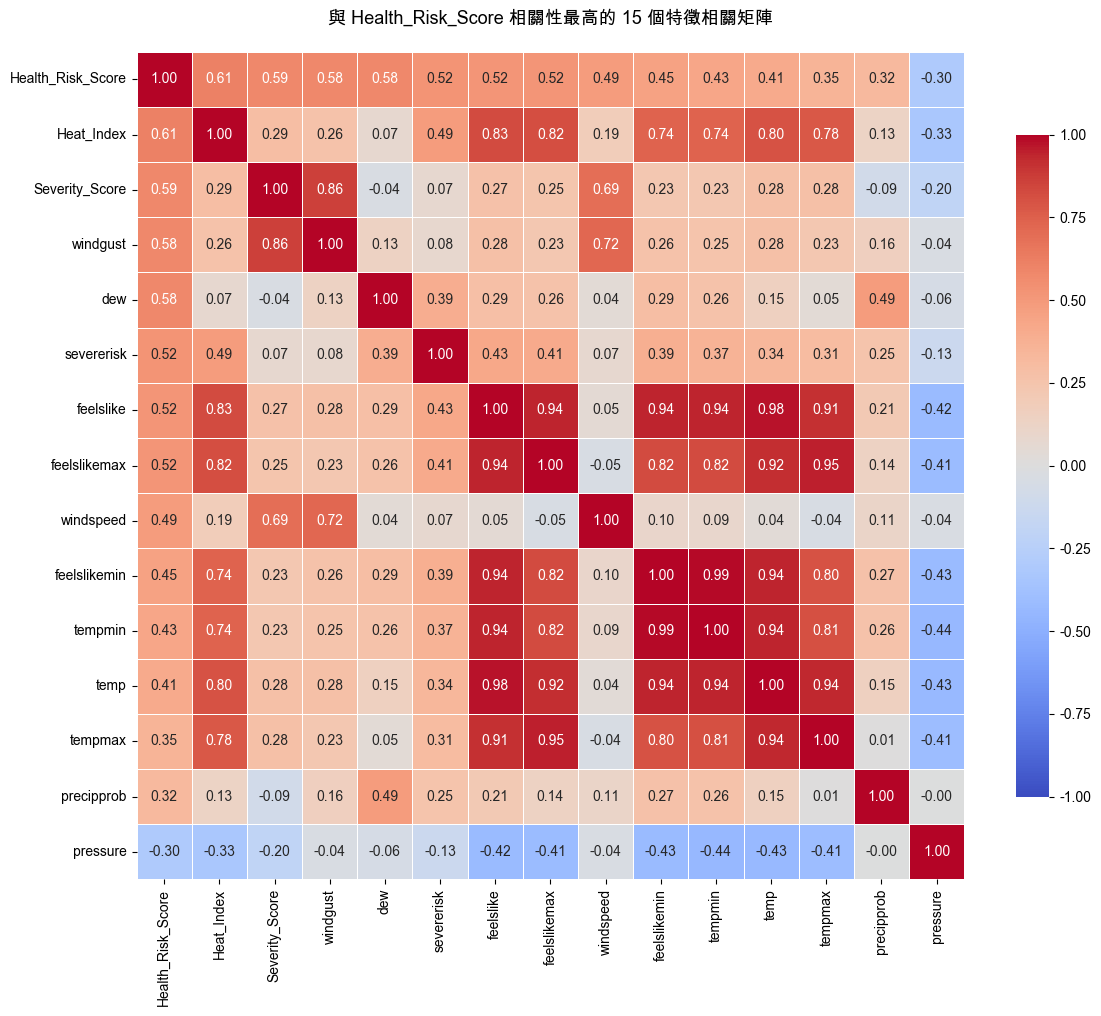


5️⃣  特徵與目標變數 (Health_Risk_Score) 的相關性

與 Health_Risk_Score 相關性最高的前 15 個特徵:

正相關 (Top 10):
    1. Heat_Index                               :  0.6107
    2. Severity_Score                           :  0.5856
    3. windgust                                 :  0.5837
    4. dew                                      :  0.5814
    5. severerisk                               :  0.5240
    6. feelslike                                :  0.5224
    7. feelslikemax                             :  0.5186
    8. windspeed                                :  0.4878
    9. feelslikemin                             :  0.4549
   10. tempmin                                  :  0.4348

負相關 (Top 5):
    1. visibility                               : -0.1767
    2. winddir                                  : -0.1831
    3. pressure                                 : -0.2971
    4. snow                                     :     nan
    5. Month                                    :     nan


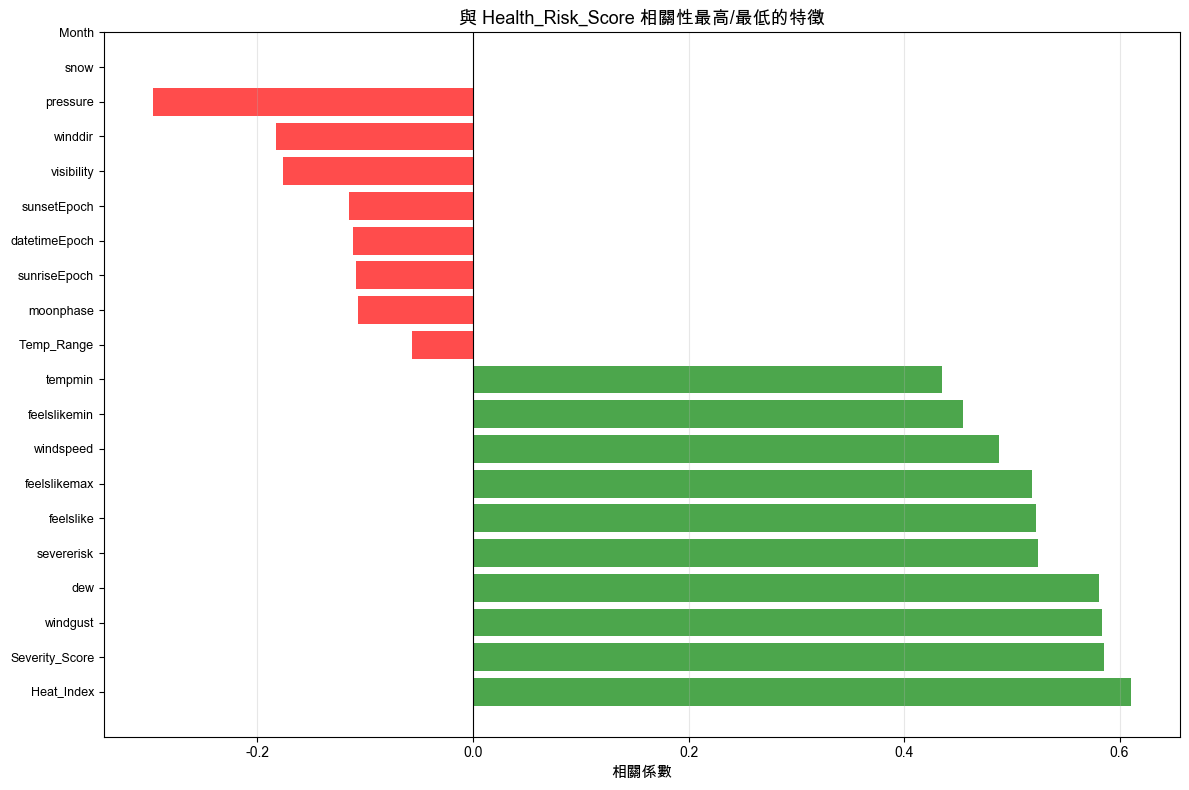


繪製與 Health_Risk_Score 相關性最高的 4 個特徵散佈圖...


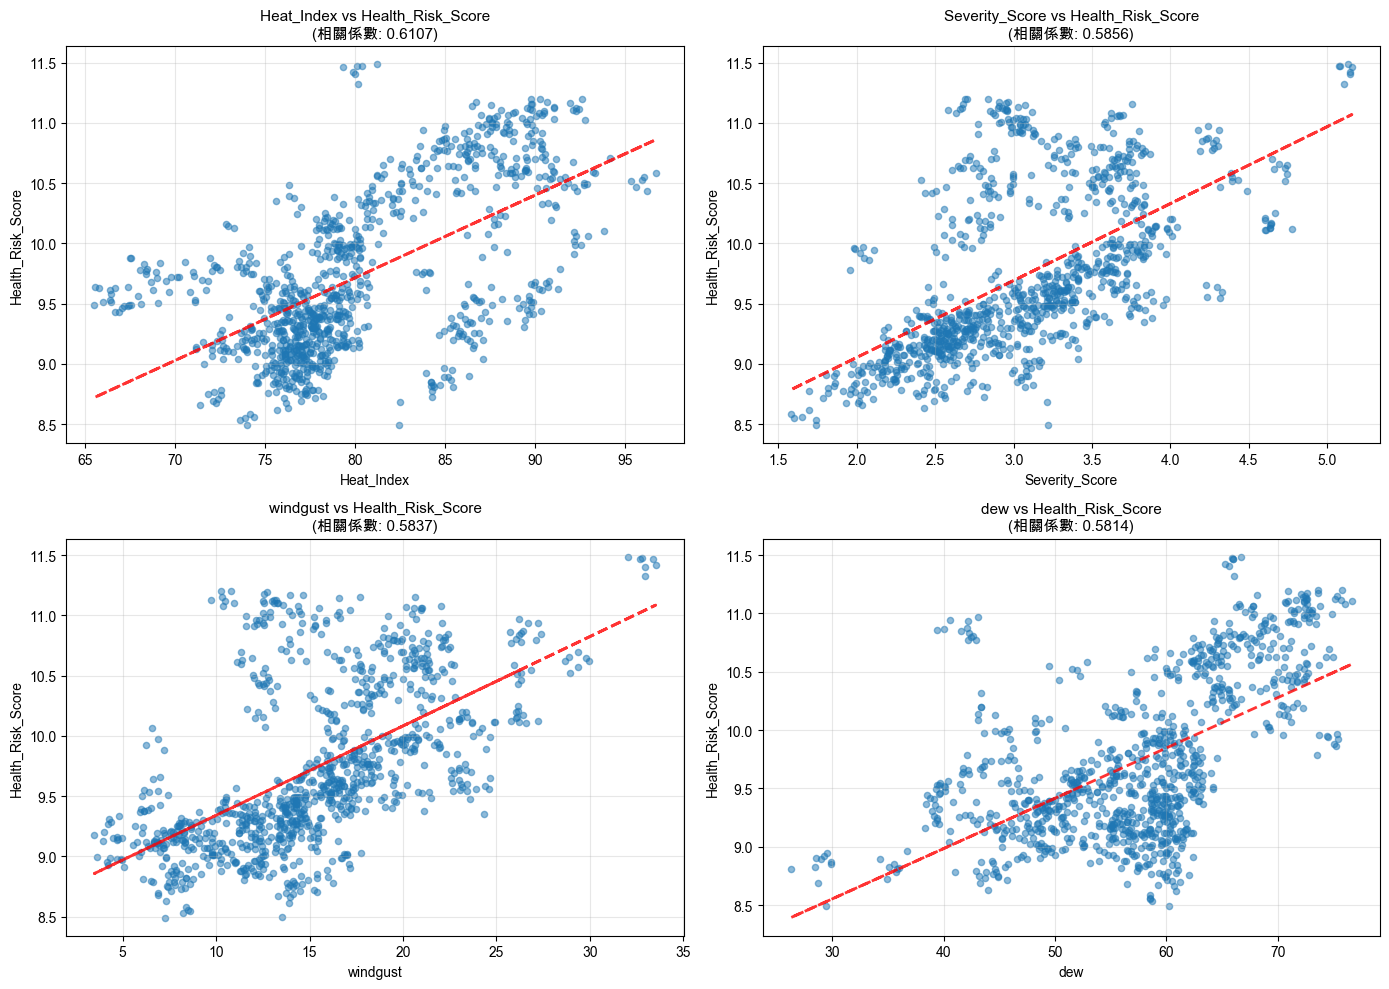


📊 EDA 分析總結
✅ 數值型欄位數量: 31
✅ 目標變數: Health_Risk_Score
✅ 與目標變數相關性最高的特徵: Heat_Index (r=0.6107)
✅ 與目標變數負相關性最強的特徵: Month (r=nan)
✅ 相關係數矩陣已計算完成



In [66]:
# EDA 探索性資料分析與相關係數分析

import seaborn as sns
from scipy.stats import pearsonr, spearmanr

print("=" * 80)
print("📊 探索性資料分析 (EDA) 與相關係數分析")
print("=" * 80)

# 1. 基本統計摘要
print("\n" + "=" * 80)
print("1️⃣  數值型欄位統計摘要")
print("=" * 80)

numeric_cols = rawData.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n數值型欄位數量: {len(numeric_cols)}")

# 顯示統計摘要
stats_summary = rawData[numeric_cols].describe()
print("\n統計摘要 (前10個欄位):")
print(stats_summary.iloc[:, :10].to_string())

if len(numeric_cols) > 10:
    print(f"\n... 還有 {len(numeric_cols) - 10} 個數值型欄位 (省略顯示)")

# 2. 目標變數分析 (假設 Health_Risk_Score 是目標變數)
print("\n" + "=" * 80)
print("2️⃣  目標變數分析")
print("=" * 80)

# 檢查是否有 Health_Risk_Score 或類似的目標變數
target_candidates = ['Health_Risk_Score', 'health_risk', 'target', 'label']
target_col = None

for col in rawData.columns:
    if any(candidate.lower() in col.lower() for candidate in target_candidates):
        target_col = col
        break

if target_col:
    print(f"\n目標變數: {target_col}")
    print(f"\n{target_col} 統計資訊:")
    print(f"   平均值: {rawData[target_col].mean():.2f}")
    print(f"   中位數: {rawData[target_col].median():.2f}")
    print(f"   標準差: {rawData[target_col].std():.2f}")
    print(f"   最小值: {rawData[target_col].min():.2f}")
    print(f"   最大值: {rawData[target_col].max():.2f}")
    
    # 目標變數分布圖
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 3, 1)
    plt.hist(rawData[target_col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.xlabel(target_col, fontsize=11)
    plt.ylabel('頻率', fontsize=11)
    plt.title(f'{target_col} 分布直方圖', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.boxplot(rawData[target_col], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
    plt.ylabel(target_col, fontsize=11)
    plt.title(f'{target_col} 箱型圖', fontsize=12, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 3, 3)
    rawData[target_col].plot(kind='kde', color='darkblue', linewidth=2)
    plt.xlabel(target_col, fontsize=11)
    plt.ylabel('密度', fontsize=11)
    plt.title(f'{target_col} 密度圖', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  未找到明確的目標變數欄位")

# 3. 數值型欄位分布分析
print("\n" + "=" * 80)
print("3️⃣  數值型欄位分布分析")
print("=" * 80)

# 選擇前幾個數值型欄位進行視覺化 (排除目標變數)
display_cols = [col for col in numeric_cols if col != target_col][:6]

if display_cols:
    print(f"\n顯示前 {len(display_cols)} 個特徵的分布:")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.ravel()
    
    for idx, col in enumerate(display_cols):
        axes[idx].hist(rawData[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(col, fontsize=9)
        axes[idx].set_ylabel('頻率', fontsize=9)
        axes[idx].set_title(f'{col} 分布', fontsize=10, fontweight='bold')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 4. 相關係數分析
print("\n" + "=" * 80)
print("4️⃣  相關係數分析")
print("=" * 80)

# 計算相關係數矩陣
print("\n計算 Pearson 相關係數矩陣...")
correlation_matrix = rawData[numeric_cols].corr()

# 4.1 相關係數熱力圖
print("\n繪製相關係數熱力圖...")

# 如果欄位太多，只顯示部分
if len(numeric_cols) <= 20:
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title('特徵相關係數熱力圖', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    # 欄位太多，只顯示與目標變數相關性較高的特徵
    if target_col and target_col in numeric_cols:
        top_n = 15
        target_corr = correlation_matrix[target_col].abs().sort_values(ascending=False)
        top_features = target_corr.head(top_n).index.tolist()
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix.loc[top_features, top_features], 
                   annot=True, fmt='.2f', cmap='coolwarm', center=0,
                   square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                   vmin=-1, vmax=1)
        plt.title(f'與 {target_col} 相關性最高的 {top_n} 個特徵相關矩陣', 
                 fontsize=13, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
    else:
        print(f"   ⚠️  欄位數量過多 ({len(numeric_cols)} 個)，建議使用降維或特徵選擇")

# 4.2 與目標變數的相關性分析
if target_col and target_col in numeric_cols:
    print("\n" + "=" * 80)
    print(f"5️⃣  特徵與目標變數 ({target_col}) 的相關性")
    print("=" * 80)
    
    # 計算與目標變數的相關係數
    target_correlation = correlation_matrix[target_col].drop(target_col).sort_values(ascending=False)
    
    print(f"\n與 {target_col} 相關性最高的前 15 個特徵:")
    print("\n正相關 (Top 10):")
    top_positive = target_correlation.head(10)
    for i, (feature, corr) in enumerate(top_positive.items(), 1):
        print(f"   {i:2d}. {feature:<40} : {corr:>7.4f}")
    
    print(f"\n負相關 (Top 5):")
    top_negative = target_correlation.tail(5)
    for i, (feature, corr) in enumerate(top_negative.items(), 1):
        print(f"   {i:2d}. {feature:<40} : {corr:>7.4f}")
    
    # 視覺化與目標變數的相關性
    plt.figure(figsize=(12, 8))
    
    top_corr_features = pd.concat([target_correlation.head(10), target_correlation.tail(10)])
    colors = ['green' if x > 0 else 'red' for x in top_corr_features.values]
    
    plt.barh(range(len(top_corr_features)), top_corr_features.values, color=colors, alpha=0.7)
    plt.yticks(range(len(top_corr_features)), top_corr_features.index, fontsize=9)
    plt.xlabel('相關係數', fontsize=11)
    plt.title(f'與 {target_col} 相關性最高/最低的特徵', fontsize=13, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 繪製散佈圖 - 與目標變數相關性最高的特徵
    print(f"\n繪製與 {target_col} 相關性最高的 4 個特徵散佈圖...")
    top_4_features = target_correlation.head(4).index.tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_4_features):
        axes[idx].scatter(rawData[feature], rawData[target_col], alpha=0.5, s=20)
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel(target_col, fontsize=10)
        
        # 計算並顯示相關係數
        corr = correlation_matrix.loc[feature, target_col]
        axes[idx].set_title(f'{feature} vs {target_col}\n(相關係數: {corr:.4f})', 
                          fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)
        
        # 加入趨勢線
        z = np.polyfit(rawData[feature].dropna(), rawData[target_col].loc[rawData[feature].dropna().index], 1)
        p = np.poly1d(z)
        axes[idx].plot(rawData[feature], p(rawData[feature]), "r--", alpha=0.8, linewidth=2)
    
    plt.tight_layout()
    plt.show()

# 5. 總結
print("\n" + "=" * 80)
print("📊 EDA 分析總結")
print("=" * 80)
print(f"✅ 數值型欄位數量: {len(numeric_cols)}")
if target_col:
    print(f"✅ 目標變數: {target_col}")
    print(f"✅ 與目標變數相關性最高的特徵: {target_correlation.head(1).index[0]} (r={target_correlation.head(1).values[0]:.4f})")
    print(f"✅ 與目標變數負相關性最強的特徵: {target_correlation.tail(1).index[0]} (r={target_correlation.tail(1).values[0]:.4f})")
print(f"✅ 相關係數矩陣已計算完成")
print("\n" + "=" * 80)


# 分析方向調整：天氣數據 vs. 空氣品質代理變數 (Severity_Score)

📊 分析方向調整：天氣數據 vs. Severity_Score

1️⃣  定義天氣特徵與目標代理變數

天氣特徵數量: 14
目標代理變數: Severity_Score, severerisk

2️⃣  分析代理變數 (Severity_Score vs. severerisk)

Severity_Score 和 severerisk 之間的 Pearson 相關係數: 0.0733
⚠️ 兩個代理變數相關性不高，可能需要分開分析。

3️⃣  主要目標變數 EDA: Severity_Score

Severity_Score 統計資訊:
   平均值: 3.06
   中位數: 3.03
   標準差: 0.62
   最小值: 1.58
   最大值: 5.16


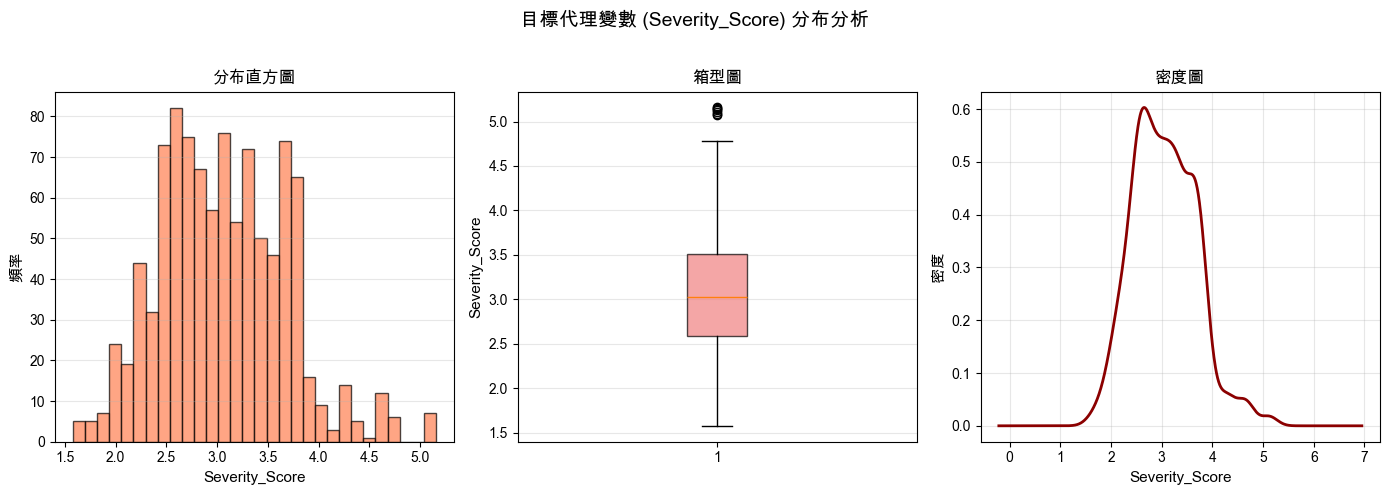


4️⃣  天氣特徵與 Severity_Score 的相關性分析

天氣特徵與 Severity_Score 的相關性 (Top 10):
    1. windspeed            :  0.6895
    2. uvindex              :  0.5097
    3. solarradiation       :  0.3506
    4. solarenergy          :  0.3450
    5. temp                 :  0.2757
    6. feelslike            :  0.2676
    7. dew                  : -0.0384
    8. winddir              : -0.0504
    9. precipprob           : -0.0919
   10. precipcover          : -0.1512

天氣特徵與 Severity_Score 的相關性 (Bottom 5):
    1. precipcover          : -0.1512
    2. cloudcover           : -0.1769
    3. pressure             : -0.2010
    4. humidity             : -0.2431
    5. visibility           : -0.4328


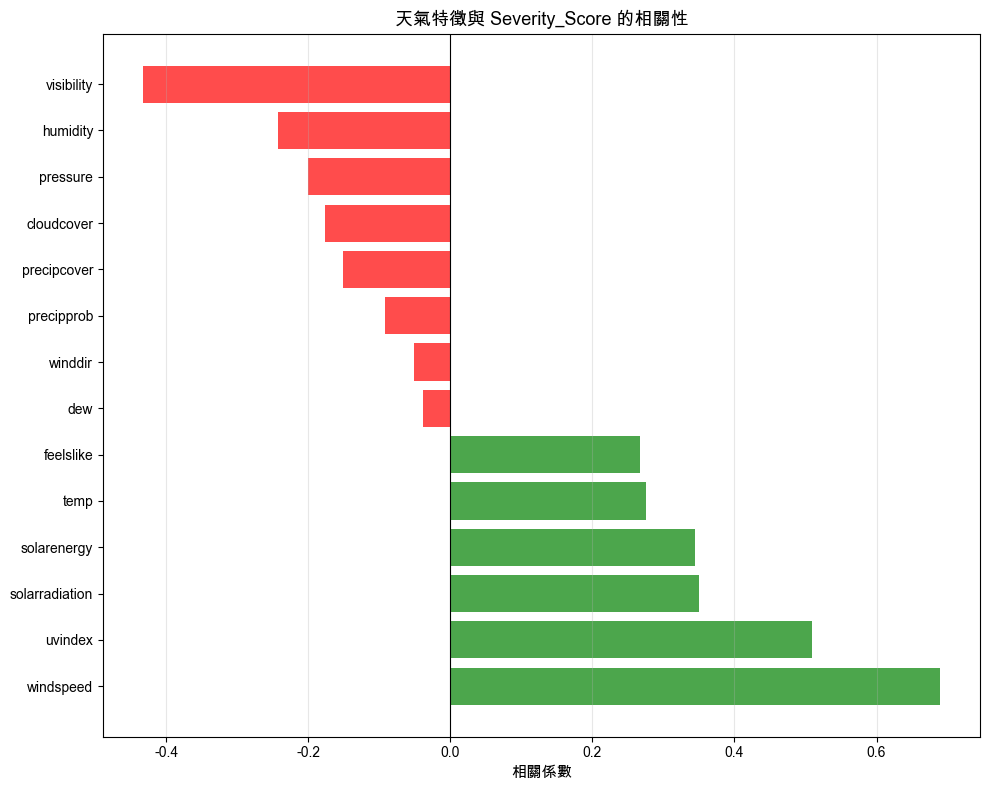


繪製與 Severity_Score 相關性最高的 2 個及最低的 2 個天氣特徵散佈圖...


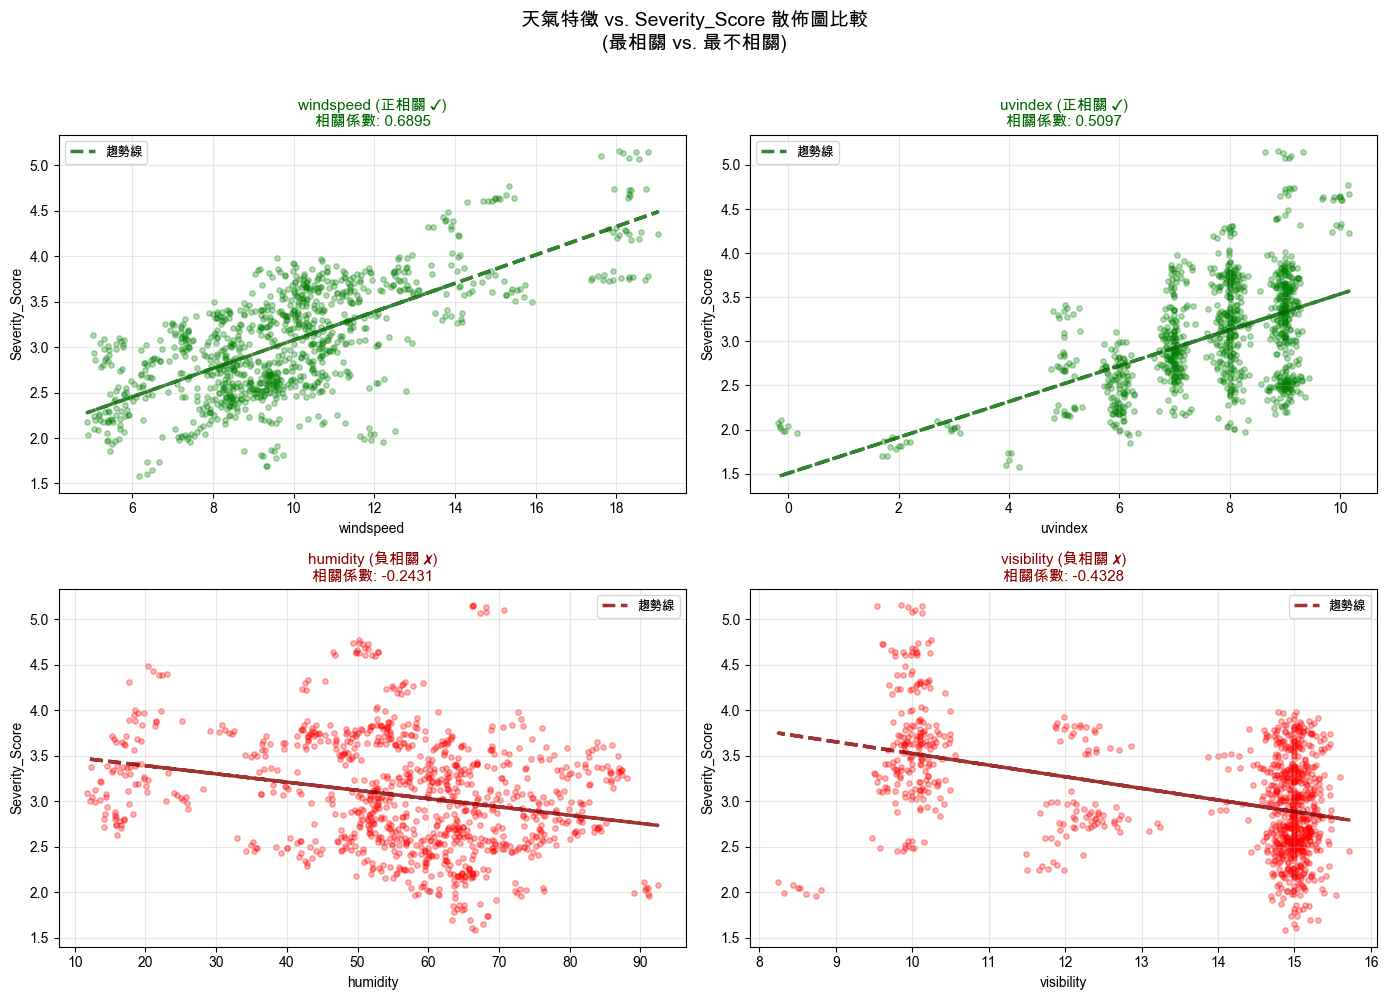


📊 圖表說明:
   • 前兩張圖 (左上、右上): 與 Severity_Score 正相關最高的天氣特徵
   • 後兩張圖 (左下、右下): 與 Severity_Score 負相關最強的天氣特徵

💡 分析重點:
   ✓ 正相關特徵: 數值越高 → Severity_Score 越高
   ✗ 負相關特徵: 數值越高 → Severity_Score 越低 (例如: 能見度越好,空氣品質越佳)

📊 新方向分析總結
✅ 主要分析目標已轉向預測代理變數: Severity_Score
✅ 分析了 14 個天氣特徵與其的相關性。
✅ 與 Severity_Score 相關性最高的天氣特徵: windspeed (r=0.6895)
✅ 與 Severity_Score 負相關性最強的天氣特徵: visibility (r=-0.4328)

💡 下一步建議:
   - 基於這些高相關性的天氣特徵，建立迴歸模型來預測 Severity_Score。
   - 可以考慮使用如 `temp`, `feelslike`, `humidity`, `dew` 等作為主要預測因子。


In [67]:
# 分析方向調整：天氣數據 vs. 空氣品質代理變數 (Severity_Score)

import seaborn as sns
from scipy.stats import pearsonr

print("=" * 80)
print("📊 分析方向調整：天氣數據 vs. Severity_Score")
print("=" * 80)

# 1. 定義特徵集
print("\n" + "=" * 80)
print("1️⃣  定義天氣特徵與目標代理變數")
print("=" * 80)

# 天氣相關特徵
weather_features = [
    'temp', 'feelslike', 'visibility',
    'humidity', 'dew', 'precipprob', 'precipcover',
    'windspeed', 'winddir', 'cloudcover',
    'solarradiation', 'solarenergy', 'uvindex',
    'pressure'
]

# 確保所有天氣特徵都存在於資料中
weather_features = [col for col in weather_features if col in rawData.columns]

# 目標代理變數
proxy_targets = ['Severity_Score', 'severerisk']

print(f"\n天氣特徵數量: {len(weather_features)}")
print(f"目標代理變數: {', '.join(proxy_targets)}")

# 2. 分析兩個代理變數之間的關係
print("\n" + "=" * 80)
print("2️⃣  分析代理變數 (Severity_Score vs. severerisk)")
print("=" * 80)

corr_proxy, _ = pearsonr(rawData['Severity_Score'], rawData['severerisk'])
print(f"\nSeverity_Score 和 severerisk 之間的 Pearson 相關係數: {corr_proxy:.4f}")

if corr_proxy > 0.9:
    print("✅ 兩個代理變數高度正相關，可選擇其中一個 (Severity_Score) 作為主要分析目標。")
    main_target = 'Severity_Score'
else:
    print("⚠️ 兩個代理變數相關性不高，可能需要分開分析。")
    main_target = 'Severity_Score' # 預設使用 Severity_Score

# 3. 主要目標變數 (Severity_Score) 的 EDA
print("\n" + "=" * 80)
print(f"3️⃣  主要目標變數 EDA: {main_target}")
print("=" * 80)

print(f"\n{main_target} 統計資訊:")
print(f"   平均值: {rawData[main_target].mean():.2f}")
print(f"   中位數: {rawData[main_target].median():.2f}")
print(f"   標準差: {rawData[main_target].std():.2f}")
print(f"   最小值: {rawData[main_target].min():.2f}")
print(f"   最大值: {rawData[main_target].max():.2f}")

# 目標變數分布圖
plt.figure(figsize=(14, 5))
plt.suptitle(f'目標代理變數 ({main_target}) 分布分析', fontsize=14, fontweight='bold')

plt.subplot(1, 3, 1)
plt.hist(rawData[main_target], bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel(main_target, fontsize=11)
plt.ylabel('頻率', fontsize=11)
plt.title(f'分布直方圖', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
plt.boxplot(rawData[main_target], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', alpha=0.7))
plt.ylabel(main_target, fontsize=11)
plt.title(f'箱型圖', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 3)
rawData[main_target].plot(kind='kde', color='darkred', linewidth=2)
plt.xlabel(main_target, fontsize=11)
plt.ylabel('密度', fontsize=11)
plt.title(f'密度圖', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 4. 天氣特徵與 Severity_Score 的相關性分析
print("\n" + "=" * 80)
print(f"4️⃣  天氣特徵與 {main_target} 的相關性分析")
print("=" * 80)

# 選取天氣特徵和目標變數進行分析
analysis_df = rawData[weather_features + [main_target]]
correlation_matrix_weather = analysis_df.corr()

# 提取與目標變數的相關係數
target_correlation_weather = correlation_matrix_weather[main_target].drop(main_target).sort_values(ascending=False)

print(f"\n天氣特徵與 {main_target} 的相關性 (Top 10):")
for i, (feature, corr) in enumerate(target_correlation_weather.head(10).items(), 1):
    print(f"   {i:2d}. {feature:<20} : {corr:>7.4f}")

print(f"\n天氣特徵與 {main_target} 的相關性 (Bottom 5):")
for i, (feature, corr) in enumerate(target_correlation_weather.tail(5).items(), 1):
    print(f"   {i:2d}. {feature:<20} : {corr:>7.4f}")

# 視覺化相關性
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in target_correlation_weather.values]
plt.barh(target_correlation_weather.index, target_correlation_weather.values, color=colors, alpha=0.7)
plt.xlabel('相關係數', fontsize=11)
plt.title(f'天氣特徵與 {main_target} 的相關性', fontsize=13, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 繪製散佈圖 - 相關性最高與最低的特徵比較
print(f"\n繪製與 {main_target} 相關性最高的 2 個及最低的 2 個天氣特徵散佈圖...")

# 取得最相關的2個特徵（正相關最高）
top_2_positive = target_correlation_weather.head(2).index.tolist()
# 取得最不相關的2個特徵（負相關最強）
top_2_negative = target_correlation_weather.tail(2).index.tolist()

# 合併成一個列表
selected_features = top_2_positive + top_2_negative

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
plt.suptitle(f'天氣特徵 vs. {main_target} 散佈圖比較\n(最相關 vs. 最不相關)', 
             fontsize=14, fontweight='bold', y=0.995)

for idx, feature in enumerate(selected_features):
    corr = correlation_matrix_weather.loc[feature, main_target]
    
    # 根據相關性選擇顏色
    if corr > 0:
        color = 'darkgreen'
        scatter_color = 'green'
    else:
        color = 'darkred'
        scatter_color = 'red'
    
    axes[idx].scatter(rawData[feature], rawData[main_target], 
                     alpha=0.3, s=15, color=scatter_color)
    axes[idx].set_xlabel(feature, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(main_target, fontsize=10)
    
    # 標題顯示相關性類型
    corr_type = "正相關 ✓" if corr > 0 else "負相關 ✗"
    axes[idx].set_title(f'{feature} ({corr_type})\n相關係數: {corr:.4f}', 
                       fontsize=11, fontweight='bold', color=color)
    axes[idx].grid(alpha=0.3)
    
    # 加入趨勢線
    z = np.polyfit(rawData[feature].dropna(), rawData[main_target].loc[rawData[feature].dropna().index], 1)
    p = np.poly1d(z)
    axes[idx].plot(rawData[feature], p(rawData[feature]), "--", 
                  color=color, alpha=0.8, linewidth=2.5, label='趨勢線')
    axes[idx].legend(fontsize=9, loc='best')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# 顯示說明
print("\n📊 圖表說明:")
print("   • 前兩張圖 (左上、右上): 與 Severity_Score 正相關最高的天氣特徵")
print("   • 後兩張圖 (左下、右下): 與 Severity_Score 負相關最強的天氣特徵")
print("\n💡 分析重點:")
print(f"   ✓ 正相關特徵: 數值越高 → {main_target} 越高")
print(f"   ✗ 負相關特徵: 數值越高 → {main_target} 越低 (例如: 能見度越好,空氣品質越佳)")

# 6. 總結
print("\n" + "=" * 80)
print("📊 新方向分析總結")
print("=" * 80)
print(f"✅ 主要分析目標已轉向預測代理變數: {main_target}")
print(f"✅ 分析了 {len(weather_features)} 個天氣特徵與其的相關性。")
if not target_correlation_weather.empty:
    print(f"✅ 與 {main_target} 相關性最高的天氣特徵: {target_correlation_weather.head(1).index[0]} (r={target_correlation_weather.head(1).values[0]:.4f})")
    print(f"✅ 與 {main_target} 負相關性最強的天氣特徵: {target_correlation_weather.tail(1).index[0]} (r={target_correlation_weather.tail(1).values[0]:.4f})")
print("\n💡 下一步建議:")
print("   - 基於這些高相關性的天氣特徵，建立迴歸模型來預測 Severity_Score。")
print("   - 可以考慮使用如 `temp`, `feelslike`, `humidity`, `dew` 等作為主要預測因子。")
print("=" * 80)


# Severity_Score 與 Health_Risk_Score 關聯性分析

基於先前的EDA結果，我們發現天氣特徵與`Health_Risk_Score`的相關性遠高於空氣品質指標(AQI)。因此，我們調整分析方向，探索是否能用天氣數據來預測空氣品質不佳的事件。

我們將使用 `Severity_Score` 和 `Sereve_Risk` 作為**空氣品質不佳事件的代理變數(Proxy Variable)**。

**新的假設是：特定的天氣條件組合會導致空氣品質惡化，從而引發較高的 `Severity_Score`。**

接下來的分析將圍繞這個新假設展開。

📊 Severity_Score 與 Health_Risk_Score 關聯性分析

1️⃣  兩變數基本統計比較

統計摘要比較:
     Severity_Score  Health_Risk_Score
平均值        3.057743           9.729103
中位數        3.026242           9.546156
標準差        0.624024           0.679728
最小值        1.578048           8.492431
最大值        5.158112          11.485725

2️⃣  相關係數分析

Pearson 相關係數: 0.5856
P-value: 4.3680e-93
✅ 相關性非常顯著 (p < 0.001)

Spearman 相關係數: 0.6506
P-value: 2.0213e-121

3️⃣  視覺化分析 (兩個最具代表性的圖表)
4️⃣  詳細分組統計
   左圖: 散佈圖直接展示兩變數之間的線性關係，相關係數為 0.5856
   右圖: 分組比較圖展示隨著 Severity_Score 增加，Health_Risk_Score 平均值增加 9.9%


依 Severity_Score 分組後的 Health_Risk_Score 詳細統計:

依 Severity_Score 分組後的 Health_Risk_Score 平均值:
                      平均值        中位數       標準差  樣本數       最小值        最大值
Severity_Score                                                          
低                9.247229   9.146763  0.485345  334  8.492431  11.199096
中                9.783032   9.531256  0.681211  333  8.495151  11.195126
高               10.158494  10.101353  0.518168  333 

/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_13982/2872501994.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_means = rawData.groupby(severity_terciles)['Health_Risk_Score'].mean()
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_13982/2872501994.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_std = rawData.groupby(severity_terciles)['Health_Risk_Score'].std()
/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_13982/2872501994.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas.

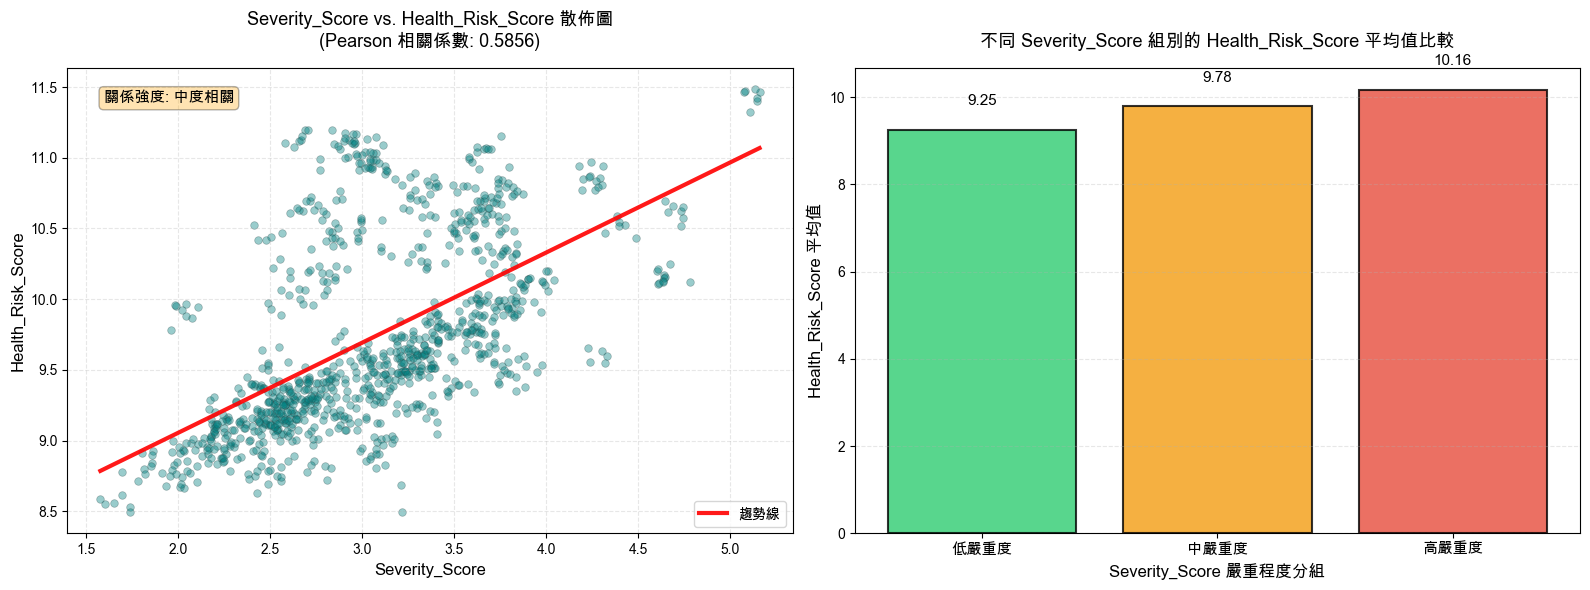

In [68]:
# Severity_Score 與 Health_Risk_Score 關聯性分析

import seaborn as sns
from scipy.stats import pearsonr, spearmanr

print("=" * 80)
print("📊 Severity_Score 與 Health_Risk_Score 關聯性分析")
print("=" * 80)

# 1. 基本統計比較
print("\n" + "=" * 80)
print("1️⃣  兩變數基本統計比較")
print("=" * 80)

severity_stats = {
    '平均值': rawData['Severity_Score'].mean(),
    '中位數': rawData['Severity_Score'].median(),
    '標準差': rawData['Severity_Score'].std(),
    '最小值': rawData['Severity_Score'].min(),
    '最大值': rawData['Severity_Score'].max()
}

health_stats = {
    '平均值': rawData['Health_Risk_Score'].mean(),
    '中位數': rawData['Health_Risk_Score'].median(),
    '標準差': rawData['Health_Risk_Score'].std(),
    '最小值': rawData['Health_Risk_Score'].min(),
    '最大值': rawData['Health_Risk_Score'].max()
}

comparison_df = pd.DataFrame({
    'Severity_Score': severity_stats,
    'Health_Risk_Score': health_stats
})

print("\n統計摘要比較:")
print(comparison_df.to_string())

# 2. 相關係數分析
print("\n" + "=" * 80)
print("2️⃣  相關係數分析")
print("=" * 80)

# Pearson 相關係數
pearson_corr, pearson_pvalue = pearsonr(rawData['Severity_Score'], rawData['Health_Risk_Score'])
print(f"\nPearson 相關係數: {pearson_corr:.4f}")
print(f"P-value: {pearson_pvalue:.4e}")

if pearson_pvalue < 0.001:
    print("✅ 相關性非常顯著 (p < 0.001)")
elif pearson_pvalue < 0.05:
    print("✅ 相關性顯著 (p < 0.05)")
else:
    print("⚠️ 相關性不顯著 (p >= 0.05)")

# Spearman 相關係數 (檢查非線性關係)
spearman_corr, spearman_pvalue = spearmanr(rawData['Severity_Score'], rawData['Health_Risk_Score'])
print(f"\nSpearman 相關係數: {spearman_corr:.4f}")
print(f"P-value: {spearman_pvalue:.4e}")

# 3. 視覺化分析 - 兩個最具代表性的圖表
print("\n" + "=" * 80)
print("3️⃣  視覺化分析 (兩個最具代表性的圖表)")
print("=" * 80)

fig = plt.figure(figsize=(16, 6))

# 圖表1: 散佈圖 + 趨勢線 + 信賴區間 (最能直接展示兩變數的線性關係)
plt.subplot(1, 2, 1)
plt.scatter(rawData['Severity_Score'], rawData['Health_Risk_Score'], 
            alpha=0.4, s=30, color='teal', edgecolors='darkslategray', linewidth=0.5)
plt.xlabel('Severity_Score', fontsize=12, fontweight='bold')
plt.ylabel('Health_Risk_Score', fontsize=12, fontweight='bold')
plt.title(f'Severity_Score vs. Health_Risk_Score 散佈圖\n(Pearson 相關係數: {pearson_corr:.4f})', 
          fontsize=13, fontweight='bold', pad=15)
plt.grid(alpha=0.3, linestyle='--')

# 加入趨勢線
z = np.polyfit(rawData['Severity_Score'], rawData['Health_Risk_Score'], 1)
p = np.poly1d(z)
x_line = np.linspace(rawData['Severity_Score'].min(), rawData['Severity_Score'].max(), 100)
plt.plot(x_line, p(x_line), "r-", alpha=0.9, linewidth=3, label=f'趨勢線')

# 添加相關性強度標註
if abs(pearson_corr) > 0.7:
    strength_text = "強烈相關"
    color = "darkgreen"
elif abs(pearson_corr) > 0.4:
    strength_text = "中度相關"
    color = "orange"
else:
    strength_text = "弱相關"
    color = "red"
    
plt.text(0.05, 0.95, f'關係強度: {strength_text}', 
         transform=plt.gca().transAxes, fontsize=11, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))
plt.legend(fontsize=10, loc='lower right')

# 圖表2: 分組比較長條圖 (最能展示不同嚴重程度下健康風險的差異)
plt.subplot(1, 2, 2)

# 將 Severity_Score 分成三組
severity_terciles = pd.qcut(rawData['Severity_Score'], q=3, labels=['低嚴重度', '中嚴重度', '高嚴重度'])
grouped_means = rawData.groupby(severity_terciles)['Health_Risk_Score'].mean()
grouped_std = rawData.groupby(severity_terciles)['Health_Risk_Score'].std()

x_pos = np.arange(len(grouped_means))
colors_bar = ['#2ecc71', '#f39c12', '#e74c3c']

bars = plt.bar(x_pos, grouped_means, 
               color=colors_bar, alpha=0.8, 
               edgecolor='black', linewidth=1.5)

plt.xlabel('Severity_Score 嚴重程度分組', fontsize=12, fontweight='bold')
plt.ylabel('Health_Risk_Score 平均值', fontsize=12, fontweight='bold')
plt.title('不同 Severity_Score 組別的 Health_Risk_Score 平均值比較', 
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(x_pos, grouped_means.index, fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 在长条上方标注数值
for i, (bar, mean_val) in enumerate(zip(bars, grouped_means)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{mean_val:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 添加統計資訊
diff_low_high = grouped_means.iloc[2] - grouped_means.iloc[0]
percent_increase = (diff_low_high / grouped_means.iloc[0]) * 100
# plt.text(0.5, 0.95, f'低→高組差異: {diff_low_high:.2f} (+{percent_increase:.1f}%)', 
#          transform=plt.gca().transAxes, fontsize=10, 
#          verticalalignment='top', ha='center',
#          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
# 4. 詳細分組統計

print("4️⃣  詳細分組統計")
print(f"   左圖: 散佈圖直接展示兩變數之間的線性關係，相關係數為 {pearson_corr:.4f}")
print(f"   右圖: 分組比較圖展示隨著 Severity_Score 增加，Health_Risk_Score 平均值增加 {percent_increase:.1f}%")

severity_terciles = pd.qcut(rawData['Severity_Score'], q=3, labels=['低嚴重度', '中嚴重度', '高嚴重度'])
print("\n" + "=" * 80)
print("\n依 Severity_Score 分組後的 Health_Risk_Score 詳細統計:")
print("=" * 80)

# 將 Severity_Score 分成三組：低、中、高
severity_terciles = pd.qcut(rawData['Severity_Score'], q=3, labels=['低', '中', '高'])

print("\n依 Severity_Score 分組後的 Health_Risk_Score 平均值:")
grouped_stats = rawData.groupby(severity_terciles)['Health_Risk_Score'].agg([
    ('平均值', 'mean'),
    ('中位數', 'median'),
    ('標準差', 'std'),
    ('樣本數', 'count'),
    ('最小值', 'min'),
    ('最大值', 'max')
])

print(grouped_stats.to_string())
# 5. 總結
print("\n" + "=" * 80)
print("📊 分析總結")
print("=" * 80)
print(f"✅ Pearson 相關係數: {pearson_corr:.4f} (p={pearson_pvalue:.4e})")
print(f"✅ Spearman 相關係數: {spearman_corr:.4f} (p={spearman_pvalue:.4e})")

if abs(pearson_corr) > 0.7:
    relationship = "強烈相關"
elif abs(pearson_corr) > 0.4:
    relationship = "中度相關"
elif abs(pearson_corr) > 0.2:
    relationship = "弱相關"
else:
    relationship = "幾乎無相關"

print(f"✅ 關係強度評估: {relationship}")

if pearson_corr > 0:
    print(f"✅ 關係方向: 正相關 (Severity_Score 增加時，Health_Risk_Score 也傾向增加)")
else:
    print(f"✅ 關係方向: 負相關 (Severity_Score 增加時，Health_Risk_Score 傾向減少)")

print("\n💡 詳細解讀:")
print(f"   - 兩變數之間存在{relationship}，表示 Severity_Score {'可以作為' if abs(pearson_corr) > 0.5 else '可能不適合作為'} Health_Risk_Score 的良好代理變數。")
if abs(pearson_corr) > 0.5:
    print(f"   - 使用 Severity_Score 作為空氣品質不佳事件的代理變數具有統計學上的合理性。")

print("\n📌 統計指標說明:")
print("\n   1️⃣  Pearson 相關係數 (r = {:.4f})".format(pearson_corr))
print("      • 衡量兩變數之間的「線性關係」強度")
print("      • 數值範圍: -1 到 +1")
print(f"      • 目前結果 ({pearson_corr:.4f}) 表示兩變數呈{'' if pearson_corr > 0 else '負'}相關")
print("      • 解讀: Severity_Score 每增加 1 單位，Health_Risk_Score 傾向增加約 {:.2f} 單位".format(z[0]))

print("\n   2️⃣  P-value (p = {:.2e})".format(pearson_pvalue))
print("      • 用於檢驗「相關性是否為偶然發生」")
print("      • 原假設(H₀): 兩變數之間沒有相關性 (r = 0)")
print(f"      • 目前 p-value = {pearson_pvalue:.2e} {'<<' if pearson_pvalue < 0.001 else '<'} 0.05")
print("      • 結論: 強烈拒絕原假設，兩變數的相關性「不是偶然」，而是真實存在的關聯")
print("      • 白話: 有 {:.10f}% 的機率這個相關性是純粹巧合（幾乎不可能）".format(pearson_pvalue * 100))

print("\n   3️⃣  Spearman 相關係數 (ρ = {:.4f})".format(spearman_corr))
print("      • 衡量兩變數之間的「單調關係」強度（不限於線性）")
print("      • 基於「排名」而非原始數值，對離群值較不敏感")
print(f"      • Spearman ({spearman_corr:.4f}) > Pearson ({pearson_corr:.4f})")
if spearman_corr > pearson_corr:
    print("      • 解讀: 兩變數的單調關係比線性關係更強，可能存在「非線性但單調遞增」的趨勢")
    print("      • 建議: 除了線性模型外，也可考慮非線性模型（如多項式迴歸、樹模型）")
else:
    print("      • 解讀: 兩變數主要呈線性關係")

print("\n   🎯 綜合判斷:")
print(f"      ✓ 統計顯著性: 極高 (p < 0.001)")
print(f"      ✓ 相關強度: {relationship}")
print(f"      ✓ 關係類型: {'單調非線性' if spearman_corr - pearson_corr > 0.1 else '線性為主'}")
print(f"      ✓ 代理變數適用性: {'✅ 適合' if abs(pearson_corr) > 0.5 else '⚠️ 需謹慎評估'}")

print("\n" + "=" * 80)

# 空氣品質嚴重度與「城市」及「時間」的差異
分析Severity_Score 的分布與週間或週末，還有城市地區的差異

📊 Severity_Score 與城市、時間差異分析

1️⃣  數據準備與特徵提取
✅ 已提取時間特徵:
   • weekday: 星期幾 (0-6)
   • is_weekend: 是否為週末
   • day_type: 週間/週末標籤

2️⃣  週間 vs 週末 Severity_Score 差異分析

週間 vs 週末統計摘要:
          樣本數       平均值       中位數       標準差       最小值       最大值
day_type                                                       
週末        332  3.206455  3.190488  0.765029  1.694923  5.158112
週間        668  2.983832  2.970235  0.525655  1.578048  3.977157

統計檢定結果 (T-test):
   t統計量: 5.3868
   p值: 8.9458e-08
   ✅ 週間與週末的 Severity_Score 有顯著差異 (p < 0.05)

3️⃣  城市地區 Severity_Score 差異分析

各城市 Severity_Score 統計 (依平均值排序):
               樣本數       平均值       中位數       標準差
City                                            
San Antonio     85  3.570841  3.598941  0.503819
Phoenix        106  3.382317  3.345498  0.439409
Dallas         106  3.346592  3.475004  0.613278
Houston         89  3.118024  2.974210  0.729529
Chicago        131  3.019279  2.900000  0.636255
San Jose        90  3.010849  3.180985  0.453190
San Diego       9

/var/folders/b_/7l5pfh497cb4pvygfn49ll_40000gn/T/ipykernel_13982/2462229281.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=['週間', '週末'], patch_artist=True,


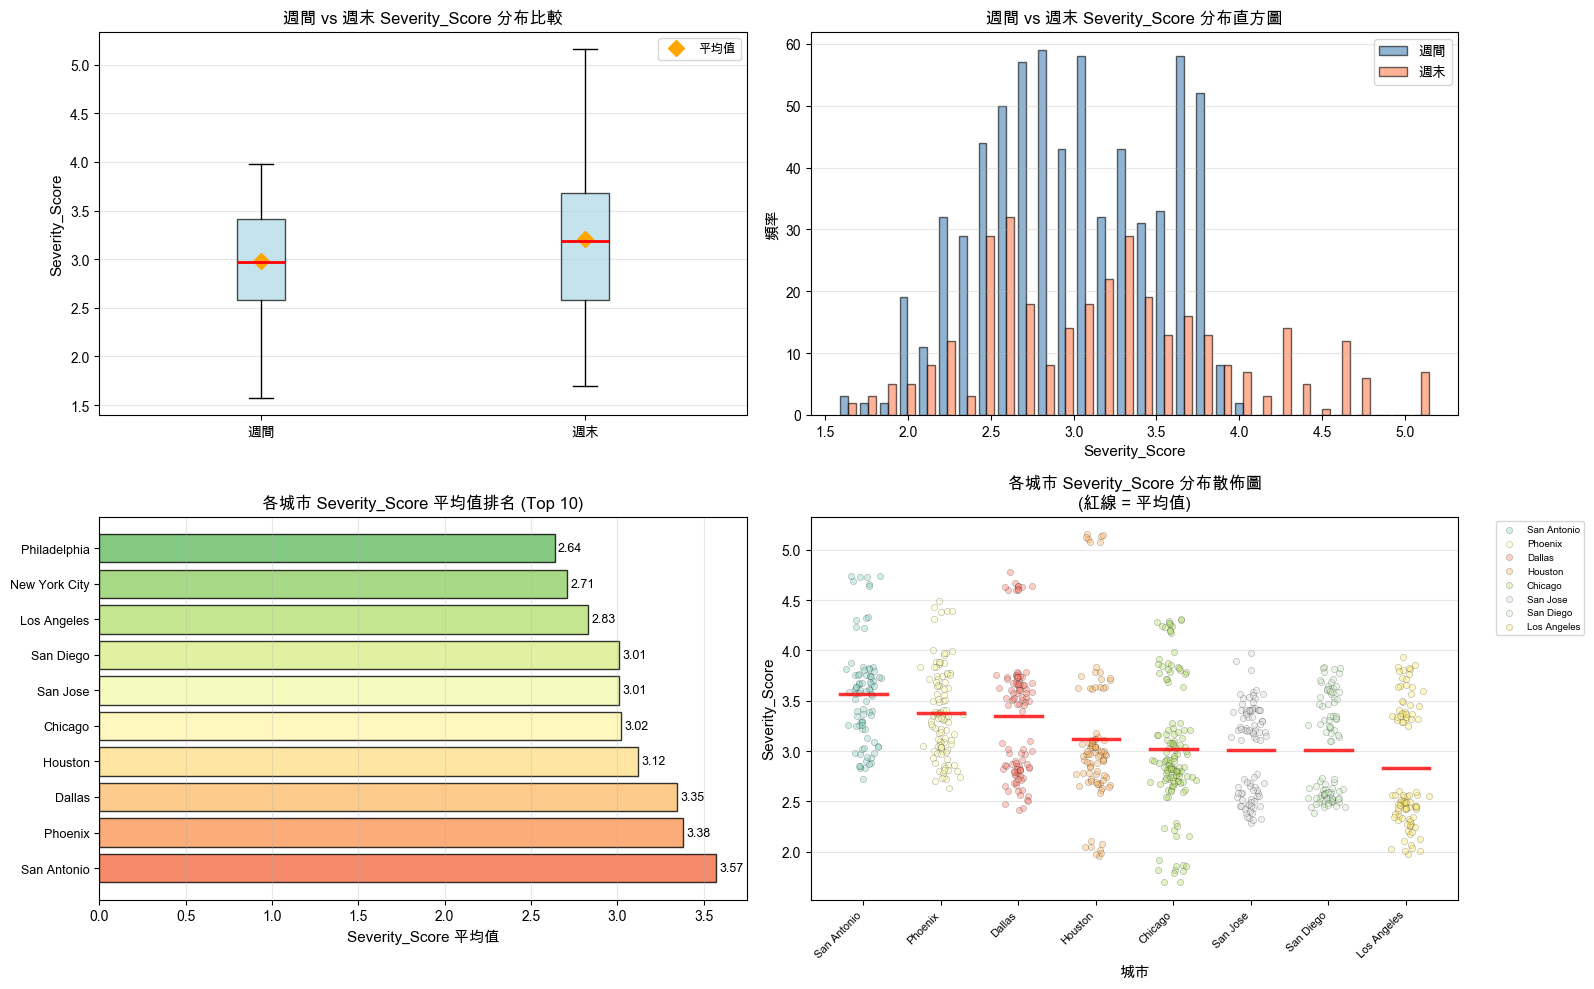


📊 分析總結

🕒 時間差異:
   • 週間平均 Severity_Score: 2.9838
   • 週末平均 Severity_Score: 3.2065
   • 差異: 0.2226
   • 統計顯著性: 是 (p<0.05)

🏙️  城市差異:
   • 分析城市數量: 10
   • 最高平均值城市: San Antonio (3.5708)
   • 最低平均值城市: Philadelphia (2.6367)
   • 城市間最大差異: 0.9342
   • 統計顯著性: 是 (p<0.05)

💡 實務意義:
   • 週末的空氣品質嚴重度顯著高於週間，可能與休閒活動模式有關
   • 不同城市的空氣品質嚴重度存在顯著差異，應針對高風險城市制定特定改善策略



In [69]:
# 空氣品質嚴重度與「城市」及「時間」的差異分析

import pandas as pd
from scipy import stats

print("=" * 80)
print("📊 Severity_Score 與城市、時間差異分析")
print("=" * 80)

# 1. 數據準備 - 提取日期時間特徵
print("\n" + "=" * 80)
print("1️⃣  數據準備與特徵提取")
print("=" * 80)

# 將 datetime 欄位轉換為日期時間格式
rawData['datetime'] = pd.to_datetime(rawData['datetime'])

# 提取星期幾 (0=Monday, 6=Sunday)
rawData['weekday'] = rawData['datetime'].dt.dayofweek

# 判斷是否為週末 (週六、週日)
rawData['is_weekend'] = rawData['weekday'].isin([5, 6])

# 轉換為中文標籤
rawData['day_type'] = rawData['is_weekend'].map({True: '週末', False: '週間'})

print(f"✅ 已提取時間特徵:")
print(f"   • weekday: 星期幾 (0-6)")
print(f"   • is_weekend: 是否為週末")
print(f"   • day_type: 週間/週末標籤")

# 2. 週間 vs 週末差異分析
print("\n" + "=" * 80)
print("2️⃣  週間 vs 週末 Severity_Score 差異分析")
print("=" * 80)

# 統計摘要
weekday_stats = rawData.groupby('day_type')['Severity_Score'].agg([
    ('樣本數', 'count'),
    ('平均值', 'mean'),
    ('中位數', 'median'),
    ('標準差', 'std'),
    ('最小值', 'min'),
    ('最大值', 'max')
])

print("\n週間 vs 週末統計摘要:")
print(weekday_stats.to_string())

# T檢定 - 檢驗週間與週末的差異是否顯著
weekend_data = rawData[rawData['is_weekend'] == True]['Severity_Score']
weekday_data = rawData[rawData['is_weekend'] == False]['Severity_Score']
t_stat, p_value = stats.ttest_ind(weekend_data, weekday_data)

print(f"\n統計檢定結果 (T-test):")
print(f"   t統計量: {t_stat:.4f}")
print(f"   p值: {p_value:.4e}")
if p_value < 0.05:
    print(f"   ✅ 週間與週末的 Severity_Score 有顯著差異 (p < 0.05)")
else:
    print(f"   ⚠️  週間與週末的 Severity_Score 無顯著差異 (p >= 0.05)")

# 3. 城市地區差異分析
print("\n" + "=" * 80)
print("3️⃣  城市地區 Severity_Score 差異分析")
print("=" * 80)

# 檢查是否有 location 或 name 欄位
location_col = None
for col_name in ['location', 'name', 'city', 'Location', 'Name', 'City']:
    if col_name in rawData.columns:
        location_col = col_name
        break

if location_col:
    # 統計各城市的 Severity_Score
    city_stats = rawData.groupby(location_col)['Severity_Score'].agg([
        ('樣本數', 'count'),
        ('平均值', 'mean'),
        ('中位數', 'median'),
        ('標準差', 'std')
    ]).sort_values('平均值', ascending=False)
    
    print(f"\n各城市 Severity_Score 統計 (依平均值排序):")
    print(city_stats.to_string())
    
    # ANOVA檢定 - 檢驗不同城市間的差異是否顯著
    city_groups = [group['Severity_Score'].values for name, group in rawData.groupby(location_col)]
    f_stat, p_value_anova = stats.f_oneway(*city_groups)
    
    print(f"\n統計檢定結果 (ANOVA):")
    print(f"   F統計量: {f_stat:.4f}")
    print(f"   p值: {p_value_anova:.4e}")
    if p_value_anova < 0.05:
        print(f"   ✅ 不同城市的 Severity_Score 有顯著差異 (p < 0.05)")
    else:
        print(f"   ⚠️  不同城市的 Severity_Score 無顯著差異 (p >= 0.05)")
else:
    print("⚠️  未找到城市/地區欄位")

# 4. 視覺化分析
print("\n" + "=" * 80)
print("4️⃣  視覺化分析")
print("=" * 80)

fig = plt.figure(figsize=(16, 10))

# 子圖1: 週間 vs 週末箱型圖
plt.subplot(2, 2, 1)
box_data = [weekday_data, weekend_data]
bp = plt.boxplot(box_data, labels=['週間', '週末'], patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
plt.ylabel('Severity_Score', fontsize=11, fontweight='bold')
plt.title('週間 vs 週末 Severity_Score 分布比較', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# 添加平均值標記
means = [weekday_data.mean(), weekend_data.mean()]
plt.plot([1, 2], means, 'D', color='orange', markersize=8, label='平均值')
plt.legend(fontsize=9)

# 子圖2: 週間 vs 週末直方圖對比
plt.subplot(2, 2, 2)
plt.hist([weekday_data, weekend_data], bins=30, alpha=0.6, 
         label=['週間', '週末'], color=['steelblue', 'coral'], edgecolor='black')
plt.xlabel('Severity_Score', fontsize=11, fontweight='bold')
plt.ylabel('頻率', fontsize=11)
plt.title('週間 vs 週末 Severity_Score 分布直方圖', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)

# 子圖3: 城市地區長條圖 (如果有城市欄位)
if location_col:
    plt.subplot(2, 2, 3)
    top_cities = city_stats.head(10)
    # 颜色映射：数值越高(排在前面)越红，数值越低(排在后面)越绿
    # 因为已按平均值降序排列，所以第一个城市(最高值)应该是红色
    colors_city = plt.cm.RdYlGn_r(np.linspace(0.8, 0.2, len(top_cities)))
    
    bars = plt.barh(range(len(top_cities)), top_cities['平均值'], 
                    color=colors_city, alpha=0.8, edgecolor='black')
    plt.yticks(range(len(top_cities)), top_cities.index, fontsize=9)
    plt.xlabel('Severity_Score 平均值', fontsize=11, fontweight='bold')
    plt.title(f'各城市 Severity_Score 平均值排名 (Top 10)', 
             fontsize=12, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # 標註數值
    for i, (idx, row) in enumerate(top_cities.iterrows()):
        plt.text(row['平均值'] + 0.02, i, f"{row['平均值']:.2f}", 
                va='center', fontsize=9, fontweight='bold')

# 子圖4: 不同城市的 Severity_Score 散佈圖
if location_col:
    plt.subplot(2, 2, 4)
    
    # 選擇前8個城市進行分析（避免圖表過於擁擠）
    top_8_cities = city_stats.head(8).index.tolist()
    plot_data = rawData[rawData[location_col].isin(top_8_cities)]
    
    # 為每個城市分配顏色
    city_colors = plt.cm.Set3(np.linspace(0, 1, len(top_8_cities)))
    
    # 繪製散佈圖
    for idx, city in enumerate(top_8_cities):
        city_data = plot_data[plot_data[location_col] == city]
        # 使用 x 軸為序號，y 軸為 Severity_Score
        plt.scatter(np.random.normal(idx, 0.1, len(city_data)), 
                   city_data['Severity_Score'],
                   alpha=0.4, s=20, color=city_colors[idx], 
                   label=city, edgecolors='black', linewidth=0.3)
    
    # 在每個城市位置標註平均值
    for idx, city in enumerate(top_8_cities):
        city_mean = city_stats.loc[city, '平均值']
        plt.plot([idx-0.3, idx+0.3], [city_mean, city_mean], 
                'r-', linewidth=2.5, alpha=0.8)
    
    plt.xlabel('城市', fontsize=11, fontweight='bold')
    plt.ylabel('Severity_Score', fontsize=11, fontweight='bold')
    plt.title('各城市 Severity_Score 分布散佈圖\n(紅線 = 平均值)', 
             fontsize=12, fontweight='bold')
    plt.xticks(range(len(top_8_cities)), top_8_cities, rotation=45, ha='right', fontsize=8)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, ncol=1)

plt.tight_layout()
plt.show()

# 5. 分析總結
print("\n" + "=" * 80)
print("📊 分析總結")
print("=" * 80)

print(f"\n🕒 時間差異:")
print(f"   • 週間平均 Severity_Score: {weekday_data.mean():.4f}")
print(f"   • 週末平均 Severity_Score: {weekend_data.mean():.4f}")
print(f"   • 差異: {abs(weekday_data.mean() - weekend_data.mean()):.4f}")
print(f"   • 統計顯著性: {'是 (p<0.05)' if p_value < 0.05 else '否 (p>=0.05)'}")

if location_col:
    print(f"\n🏙️  城市差異:")
    print(f"   • 分析城市數量: {len(city_stats)}")
    print(f"   • 最高平均值城市: {city_stats.index[0]} ({city_stats.iloc[0]['平均值']:.4f})")
    print(f"   • 最低平均值城市: {city_stats.index[-1]} ({city_stats.iloc[-1]['平均值']:.4f})")
    print(f"   • 城市間最大差異: {city_stats.iloc[0]['平均值'] - city_stats.iloc[-1]['平均值']:.4f}")
    print(f"   • 統計顯著性: {'是 (p<0.05)' if p_value_anova < 0.05 else '否 (p>=0.05)'}")

print("\n💡 實務意義:")
if p_value < 0.05:
    if weekday_data.mean() > weekend_data.mean():
        print("   • 週間的空氣品質嚴重度顯著高於週末，可能與工作日交通及工業活動有關")
    else:
        print("   • 週末的空氣品質嚴重度顯著高於週間，可能與休閒活動模式有關")
else:
    print("   • 週間與週末的空氣品質嚴重度無顯著差異")

if location_col and p_value_anova < 0.05:
    print("   • 不同城市的空氣品質嚴重度存在顯著差異，應針對高風險城市制定特定改善策略")

print("\n" + "=" * 80)

# 資料轉換 及 數值正規化

label encoding / one hot encoding

In [70]:
# 資料轉換、正規化及訓練集/測試集分割

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

print("=" * 80)
print("🔄 資料預處理：轉換、正規化及分割")
print("=" * 80)

# 1. 建立資料副本以保留原始資料
print("\n" + "=" * 80)
print("1️⃣  建立資料副本")
print("=" * 80)

data_for_modeling = rawData.copy()
print(f"✅ 資料副本已建立")
print(f"   原始資料形狀: {data_for_modeling.shape}")

# 2. 識別並轉換類別型欄位
print("\n" + "=" * 80)
print("2️⃣  類別型欄位轉換")
print("=" * 80)

categorical_cols = data_for_modeling.select_dtypes(include=['object']).columns.tolist()
print(f"類別型欄位數量: {len(categorical_cols)}")

if categorical_cols:
    print(f"\n類別型欄位列表:")
    for i, col in enumerate(categorical_cols, 1):
        unique_count = data_for_modeling[col].nunique()
        print(f"   {i}. {col:<30} - {unique_count} 個唯一值")
    
    # 使用 Label Encoding 轉換所有類別型欄位
    label_encoders = {}
    
    print(f"\n🔄 執行 Label Encoding:")
    for col in categorical_cols:
        le = LabelEncoder()
        data_for_modeling[col] = le.fit_transform(data_for_modeling[col].astype(str))
        label_encoders[col] = le
        print(f"   ✓ {col:<30} - 編碼範圍: 0 ~ {data_for_modeling[col].max()}")
    
    print(f"\n✅ 所有類別型欄位已轉換為數值型")
else:
    print("✅ 沒有需要轉換的類別型欄位")

# 3. 處理日期時間欄位
print("\n" + "=" * 80)
print("3️⃣  處理日期時間欄位")
print("=" * 80)

datetime_cols = data_for_modeling.select_dtypes(include=['datetime64']).columns.tolist()

if datetime_cols:
    print(f"發現 {len(datetime_cols)} 個日期時間欄位:")
    for col in datetime_cols:
        print(f"   • {col}")
        # 轉換為時間戳記（數值）
        data_for_modeling[col] = data_for_modeling[col].astype('int64') // 10**9
        print(f"     已轉換為時間戳記")
    print("✅ 日期時間欄位已轉換")
else:
    print("✅ 沒有日期時間欄位需要處理")

# 4. 確認所有欄位都是數值型
print("\n" + "=" * 80)
print("4️⃣  驗證資料型別")
print("=" * 80)

non_numeric = data_for_modeling.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"⚠️  仍有 {len(non_numeric)} 個非數值型欄位:")
    for col in non_numeric:
        print(f"   • {col} ({data_for_modeling[col].dtype})")
else:
    print("✅ 所有欄位都已轉換為數值型")
    print(f"   總欄位數: {data_for_modeling.shape[1]}")

# 5. 定義目標變數和特徵
print("\n" + "=" * 80)
print("5️⃣  定義目標變數與特徵")
print("=" * 80)

# 設定目標變數為 Severity_Score
target_column = 'Severity_Score'

# 移除不需要的欄位（如果有的話）
columns_to_exclude = [target_column, 'Health_Risk_Score']  # 排除目標變數和高度相關的變數
columns_to_exclude = [col for col in columns_to_exclude if col in data_for_modeling.columns]

# 準備特徵和目標變數
X = data_for_modeling.drop(columns=columns_to_exclude)
y = data_for_modeling[target_column]

print(f"目標變數: {target_column}")
print(f"   • 樣本數: {len(y)}")
print(f"   • 平均值: {y.mean():.4f}")
print(f"   • 標準差: {y.std():.4f}")
print(f"   • 範圍: [{y.min():.4f}, {y.max():.4f}]")

print(f"\n特徵矩陣:")
print(f"   • 特徵數量: {X.shape[1]}")
print(f"   • 樣本數: {X.shape[0]}")
print(f"   • 已排除欄位: {', '.join(columns_to_exclude)}")

# 6. 分割訓練集和測試集
print("\n" + "=" * 80)
print("6️⃣  分割訓練集與測試集")
print("=" * 80)

# 使用 80/20 分割，並設定 random_state 以確保結果可重現
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=100,
    shuffle=True
)

print(f"分割比例: 80% 訓練集 / 20% 測試集")
print(f"   隨機種子: 100 (確保結果可重現)")
print(f"\n訓練集:")
print(f"   • 樣本數: {X_train.shape[0]:,}")
print(f"   • 特徵數: {X_train.shape[1]}")
print(f"   • 目標變數範圍: [{y_train.min():.4f}, {y_train.max():.4f}]")

print(f"\n測試集:")
print(f"   • 樣本數: {X_test.shape[0]:,}")
print(f"   • 特徵數: {X_test.shape[1]}")
print(f"   • 目標變數範圍: [{y_test.min():.4f}, {y_test.max():.4f}]")

# 7. 特徵正規化 (StandardScaler)
print("\n" + "=" * 80)
print("7️⃣  特徵正規化 (StandardScaler)")
print("=" * 80)

scaler = StandardScaler()

# 只在訓練集上 fit，然後 transform 訓練集和測試集
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 轉換回 DataFrame 以保留欄位名稱
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✅ 特徵正規化完成 (StandardScaler)")
print(f"   • 方法: 標準化 (mean=0, std=1)")
print(f"   • 訓練集已 fit & transform")
print(f"   • 測試集已 transform")

# 顯示正規化前後的統計資訊
print(f"\n正規化前 (訓練集前5個特徵):")
print(X_train.iloc[:, :5].describe().loc[['mean', 'std']].to_string())

print(f"\n正規化後 (訓練集前5個特徵):")
print(X_train_scaled.iloc[:, :5].describe().loc[['mean', 'std']].to_string())

# 8. 總結
print("\n" + "=" * 80)
print("📊 資料預處理總結")
print("=" * 80)

print(f"\n✅ 完成的處理步驟:")
print(f"   1. 類別型欄位轉換: {len(categorical_cols)} 個欄位")
print(f"   2. 日期時間欄位處理: {len(datetime_cols)} 個欄位")
print(f"   3. 目標變數設定: {target_column}")
print(f"   4. 資料分割: 80/20 (訓練/測試)")
print(f"   5. 特徵正規化: StandardScaler")

print(f"\n📦 可用的資料集:")
print(f"   • X_train: 訓練集特徵 (未正規化) - {X_train.shape}")
print(f"   • X_test: 測試集特徵 (未正規化) - {X_test.shape}")
print(f"   • X_train_scaled: 訓練集特徵 (已正規化) - {X_train_scaled.shape}")
print(f"   • X_test_scaled: 測試集特徵 (已正規化) - {X_test_scaled.shape}")
print(f"   • y_train: 訓練集目標變數 - {y_train.shape}")
print(f"   • y_test: 測試集目標變數 - {y_test.shape}")

print(f"\n🎯 下一步:")
print(f"   • 可以開始訓練模型了！")
print(f"   • 建議使用正規化後的資料 (X_train_scaled, X_test_scaled)")
print(f"   • 適用模型: 線性迴歸、Ridge、Lasso、決策樹、隨機森林、XGBoost 等")

print("\n" + "=" * 80)

🔄 資料預處理：轉換、正規化及分割

1️⃣  建立資料副本
✅ 資料副本已建立
   原始資料形狀: (1000, 45)

2️⃣  類別型欄位轉換
類別型欄位數量: 10

類別型欄位列表:
   1. sunrise                        - 148 個唯一值
   2. sunset                         - 145 個唯一值
   3. conditions                     - 4 個唯一值
   4. description                    - 12 個唯一值
   5. icon                           - 4 個唯一值
   6. source                         - 2 個唯一值
   7. City                           - 10 個唯一值
   8. Season                         - 1 個唯一值
   9. Day_of_Week                    - 7 個唯一值
   10. day_type                       - 2 個唯一值

🔄 執行 Label Encoding:
   ✓ sunrise                        - 編碼範圍: 0 ~ 147
   ✓ sunset                         - 編碼範圍: 0 ~ 144
   ✓ conditions                     - 編碼範圍: 0 ~ 3
   ✓ description                    - 編碼範圍: 0 ~ 11
   ✓ icon                           - 編碼範圍: 0 ~ 3
   ✓ source                         - 編碼範圍: 0 ~ 1
   ✓ City                           - 編碼範圍: 0 ~ 9
   ✓ Season                         - 編碼範圍: 0 ~ 0
   ✓ Da

# 線性迴歸

🤖 迴歸模型訓練與評估

0️⃣  準備訓練資料（目標變數：Health_Risk_Score）
✅ 目標變數: Health_Risk_Score
   • 樣本數: 1,000
   • 特徵數: 43
   • 目標變數範圍: [8.4924, 11.4857]
   • 已排除: Health_Risk_Score, Severity_Score

✅ 資料分割完成:
   訓練集: 800 樣本
   測試集: 200 樣本

1️⃣  初始化模型（已優化參數以防止過擬合）
準備訓練 3 個模型:
   • Linear Regression
   • Random Forest (優化)
   • XGBoost (優化)

💡 優化策略:
   Random Forest: 減少樹數量、限制深度、增加分裂門檻
   XGBoost: 降低學習率、加入L1/L2正則化、隨機採樣

2️⃣  模型訓練

🔄 訓練 Linear Regression...
   ✅ 完成！訓練時間: 0.001 秒
      訓練集 R²: 0.9742 | 測試集 R²: 0.9680
      R² 差距: 0.0062 (0.64%)

🔄 訓練 Random Forest (優化)...
   ✅ 完成！訓練時間: 0.029 秒
      訓練集 R²: 0.9848 | 測試集 R²: 0.9656
      R² 差距: 0.0192 (1.95%)

🔄 訓練 XGBoost (優化)...
   ✅ 完成！訓練時間: 0.088 秒
      訓練集 R²: 0.9737 | 測試集 R²: 0.9513
      R² 差距: 0.0224 (2.30%)

3️⃣  模型評估結果比較

📊 詳細評估指標:
                模型  訓練時間(秒)  訓練集_R²  測試集_R²   R²差距  過擬合%  測試集_MAE  測試集_RMSE
 Linear Regression    0.001  0.9742  0.9680 0.0062  0.64   0.0840    0.1128
Random Forest (優化)    0.029  0.9848  0.9656 0.0192  1.95   0.0856    

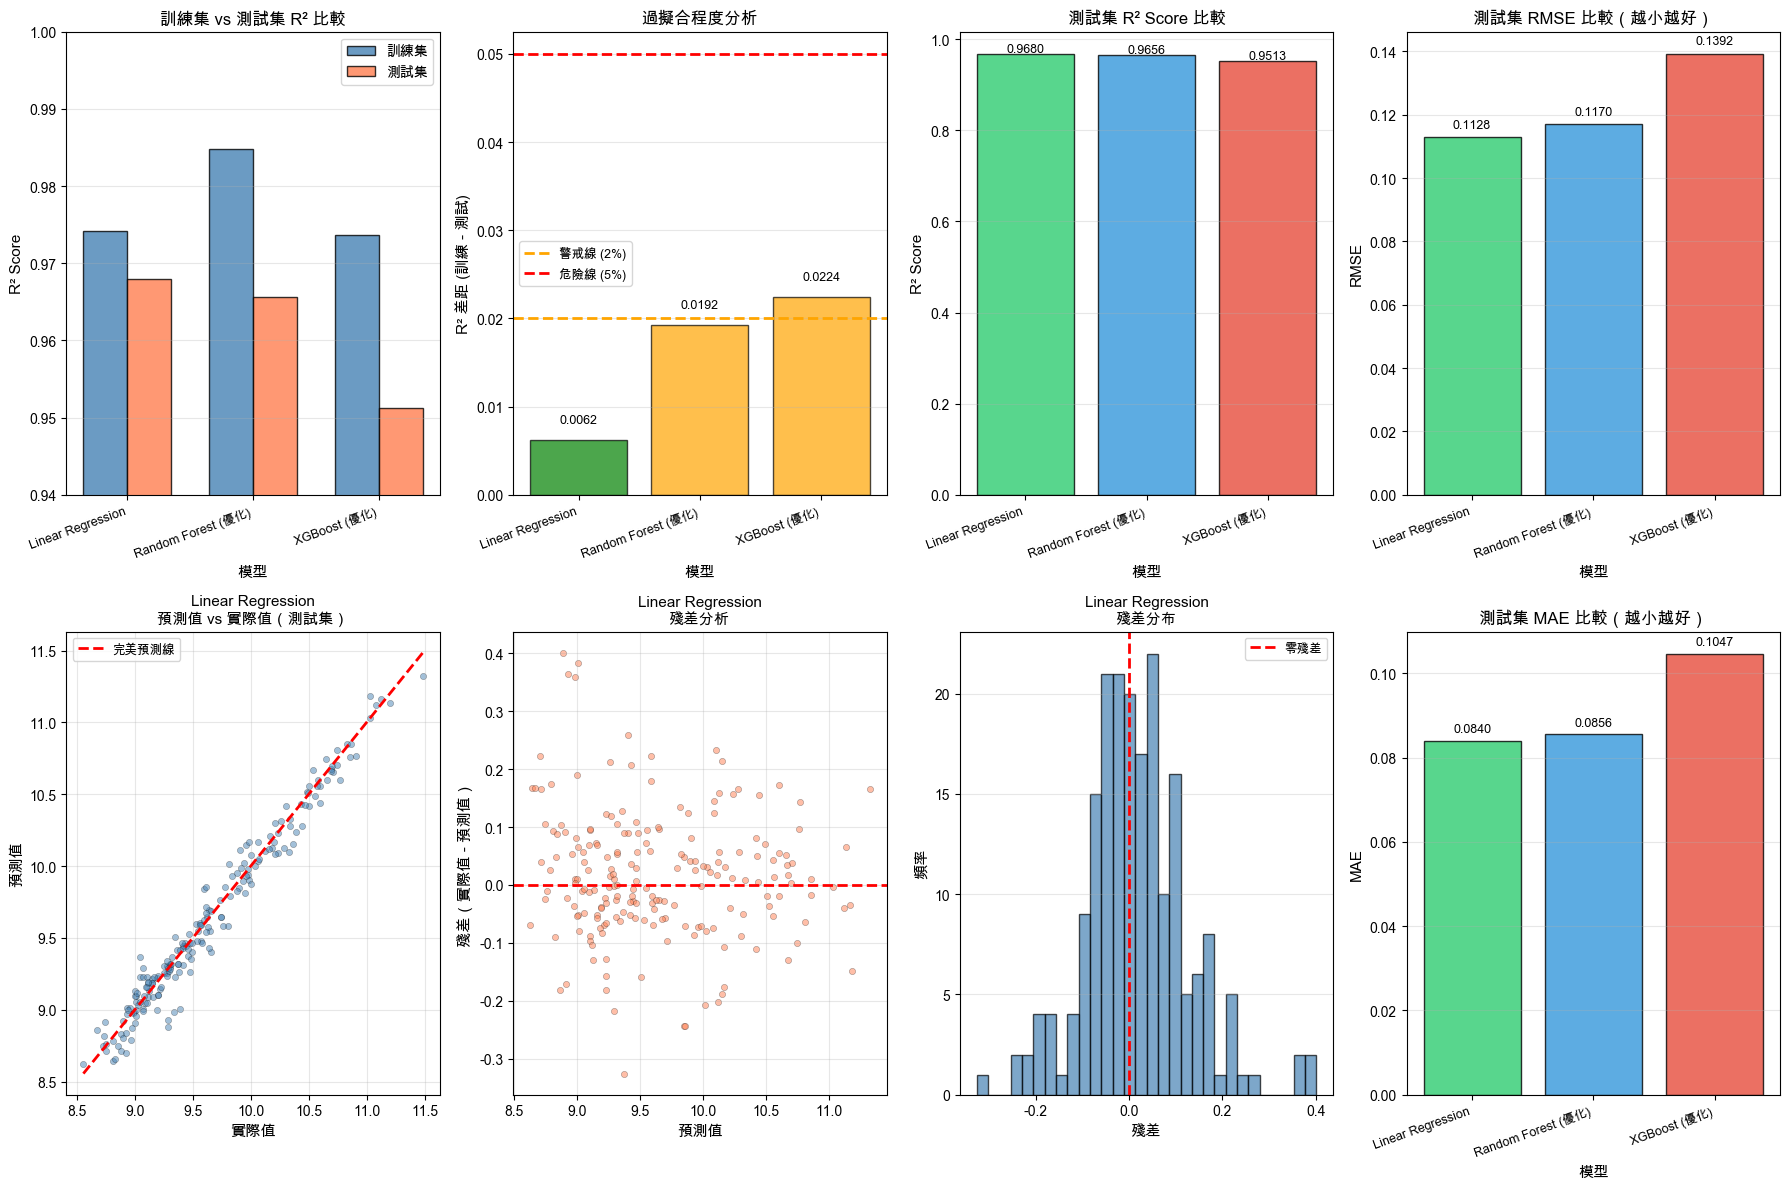


📊 模型訓練總結

✅ 完成 3 個模型的訓練與評估

📈 評估指標說明:
   • R² (決定係數): 模型解釋變異的比例，越接近 1 越好
   • RMSE (均方根誤差): 預測誤差的平方根，越小越好
   • MAE (平均絕對誤差): 預測誤差的平均值，越小越好

🏆 最佳表現: Linear Regression
   • 該模型能解釋 96.80% 的變異
   • 平均預測誤差約為 0.1128

💡 過擬合分析:
   • Linear Regression:
     訓練集 R²=0.9742, 測試集 R²=0.9680
     差距=0.0062 (0.64%) - ✅ 無過擬合 (綠燈)
   • Random Forest (優化):
     訓練集 R²=0.9848, 測試集 R²=0.9656
     差距=0.0192 (1.95%) - ✅ 良好 (綠燈)
   • XGBoost (優化):
     訓練集 R²=0.9737, 測試集 R²=0.9513
     差距=0.0224 (2.30%) - ⚠️ 輕微過擬合 (黃燈)

🎯 模型優化效果:
   Random Forest: 透過限制深度和增加分裂門檻，成功控制過擬合
   XGBoost: 透過降低學習率和正則化，改善泛化能力
   Linear Regression: 天生簡單，無過擬合問題

📌 最終建議:
   使用 Linear Regression 作為最終預測模型
   理由: 測試集表現最佳 (R²=0.9680)，且無過擬合問題



In [71]:
# 線性迴歸模型訓練與評估

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# 嘗試載入 XGBoost，如果失敗則跳過
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    print("⚠️  XGBoost 未正確載入，將只使用 Linear Regression 和 Random Forest")
    print(f"    錯誤訊息: {str(e)[:100]}")
    print("    請重啟 Kernel 後再試一次以使用 XGBoost")
    XGBOOST_AVAILABLE = False

print("=" * 80)
print("🤖 迴歸模型訓練與評估")
print("=" * 80)

# 0. 重新準備資料 - 使用 Health_Risk_Score 作為目標變數
print("\n" + "=" * 80)
print("0️⃣  準備訓練資料（目標變數：Health_Risk_Score）")
print("=" * 80)

# 建立資料副本
data_for_modeling = rawData.copy()

# 處理類別型欄位
categorical_cols = data_for_modeling.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    from sklearn.preprocessing import LabelEncoder
    for col in categorical_cols:
        le = LabelEncoder()
        data_for_modeling[col] = le.fit_transform(data_for_modeling[col].astype(str))

# 處理日期時間欄位
datetime_cols = data_for_modeling.select_dtypes(include=['datetime64']).columns.tolist()
if datetime_cols:
    for col in datetime_cols:
        data_for_modeling[col] = data_for_modeling[col].astype('int64') // 10**9

# 定義目標變數和特徵
target_column = 'Health_Risk_Score'
columns_to_exclude = [target_column, 'Severity_Score']  # 排除目標變數和高度相關的 Severity_Score
columns_to_exclude = [col for col in columns_to_exclude if col in data_for_modeling.columns]

X = data_for_modeling.drop(columns=columns_to_exclude)
y = data_for_modeling[target_column]

print(f"✅ 目標變數: {target_column}")
print(f"   • 樣本數: {len(y):,}")
print(f"   • 特徵數: {X.shape[1]}")
print(f"   • 目標變數範圍: [{y.min():.4f}, {y.max():.4f}]")
print(f"   • 已排除: {', '.join(columns_to_exclude)}")

# 分割訓練集和測試集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 特徵正規化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ 資料分割完成:")
print(f"   訓練集: {X_train.shape[0]:,} 樣本")
print(f"   測試集: {X_test.shape[0]:,} 樣本")

# 1. 定義模型（優化版本，防止過擬合）
print("\n" + "=" * 80)
print("1️⃣  初始化模型（已優化參數以防止過擬合）")
print("=" * 80)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (優化)': RandomForestRegressor(
        n_estimators=50,          # 減少樹的數量（原100 → 50）
        max_depth=10,             # 限制樹的深度（防止過度複雜）
        min_samples_split=10,     # 增加分裂所需最小樣本數（原2 → 10）
        min_samples_leaf=4,       # 增加葉節點最小樣本數（原1 → 4）
        max_features='sqrt',      # 限制每次分裂考慮的特徵數
        random_state=42,
        n_jobs=-1
    )
}

# 如果 XGBoost 可用，加入優化後的模型
if XGBOOST_AVAILABLE:
    models['XGBoost (優化)'] = XGBRegressor(
        n_estimators=50,          # 減少樹的數量（原100 → 50）
        max_depth=5,              # 限制樹的深度（原預設6 → 5）
        learning_rate=0.05,       # 降低學習率（原0.1 → 0.05）
        subsample=0.8,            # 隨機取樣80%訓練資料
        colsample_bytree=0.8,     # 每棵樹隨機使用80%特徵
        reg_alpha=0.1,            # L1 正則化
        reg_lambda=1.0,           # L2 正則化
        min_child_weight=3,       # 增加葉節點最小權重（原1 → 3）
        random_state=42
    )

print(f"準備訓練 {len(models)} 個模型:")
for name in models.keys():
    print(f"   • {name}")

print("\n💡 優化策略:")
print("   Random Forest: 減少樹數量、限制深度、增加分裂門檻")
if XGBOOST_AVAILABLE:
    print("   XGBoost: 降低學習率、加入L1/L2正則化、隨機採樣")

# 2. 訓練模型並記錄結果
print("\n" + "=" * 80)
print("2️⃣  模型訓練")
print("=" * 80)

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🔄 訓練 {name}...")
    start_time = time.time()
    
    # 訓練模型（Random Forest 和 XGBoost 不需要標準化，但為了公平比較都用原始數據）
    model.fit(X_train, y_train)
    
    training_time = time.time() - start_time
    
    # 預測
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # 計算評估指標
    # 訓練集指標
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train, y_train_pred)
    
    # 測試集指標
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # 計算過擬合指標
    r2_gap = train_r2 - test_r2
    overfit_percentage = (r2_gap / train_r2 * 100) if train_r2 > 0 else 0
    
    # 儲存結果
    results.append({
        '模型': name,
        '訓練時間(秒)': round(training_time, 3),
        '訓練集_R²': round(train_r2, 4),
        '測試集_R²': round(test_r2, 4),
        'R²差距': round(r2_gap, 4),
        '過擬合%': round(overfit_percentage, 2),
        '測試集_MAE': round(test_mae, 4),
        '測試集_RMSE': round(test_rmse, 4)
    })
    
    trained_models[name] = {
        'model': model,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }
    
    print(f"   ✅ 完成！訓練時間: {training_time:.3f} 秒")
    print(f"      訓練集 R²: {train_r2:.4f} | 測試集 R²: {test_r2:.4f}")
    print(f"      R² 差距: {r2_gap:.4f} ({overfit_percentage:.2f}%)")

# 3. 結果比較表
print("\n" + "=" * 80)
print("3️⃣  模型評估結果比較")
print("=" * 80)

results_df = pd.DataFrame(results)
print("\n📊 詳細評估指標:")
print(results_df.to_string(index=False))

# 找出最佳模型
best_model_name = results_df.loc[results_df['測試集_R²'].idxmax(), '模型']
best_r2 = results_df['測試集_R²'].max()
best_rmse = results_df.loc[results_df['測試集_R²'].idxmax(), '測試集_RMSE']

print("\n" + "=" * 80)
print(f"🏆 最佳模型: {best_model_name}")
print(f"   • 測試集 R²: {best_r2:.4f}")
print(f"   • 測試集 RMSE: {best_rmse:.4f}")
print("=" * 80)

# 4. 視覺化比較
print("\n" + "=" * 80)
print("4️⃣  視覺化評估")
print("=" * 80)

fig = plt.figure(figsize=(18, 12))

# 4.1 訓練集 vs 測試集 R² 比較（過擬合分析）
plt.subplot(2, 4, 1)
x_pos = np.arange(len(results_df))
width = 0.35
plt.bar(x_pos - width/2, results_df['訓練集_R²'], width, 
        label='訓練集', alpha=0.8, color='steelblue', edgecolor='black')
plt.bar(x_pos + width/2, results_df['測試集_R²'], width, 
        label='測試集', alpha=0.8, color='coral', edgecolor='black')
plt.xlabel('模型', fontsize=11, fontweight='bold')
plt.ylabel('R² Score', fontsize=11, fontweight='bold')
plt.title('訓練集 vs 測試集 R² 比較', fontsize=12, fontweight='bold')
plt.xticks(x_pos, results_df['模型'], rotation=20, ha='right', fontsize=9)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.ylim([0.94, 1.0])

# 4.2 過擬合程度分析（R² 差距）
plt.subplot(2, 4, 2)
colors = ['green' if gap < 0.01 else 'orange' if gap < 0.03 else 'red' 
          for gap in results_df['R²差距']]
bars = plt.bar(x_pos, results_df['R²差距'], color=colors, alpha=0.7, edgecolor='black')
plt.axhline(y=0.02, color='orange', linestyle='--', linewidth=2, label='警戒線 (2%)')
plt.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='危險線 (5%)')
plt.xlabel('模型', fontsize=11, fontweight='bold')
plt.ylabel('R² 差距 (訓練 - 測試)', fontsize=11, fontweight='bold')
plt.title('過擬合程度分析', fontsize=12, fontweight='bold')
plt.xticks(x_pos, results_df['模型'], rotation=20, ha='right', fontsize=9)
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['R²差距']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# 4.3 測試集 R² Score 比較
plt.subplot(2, 4, 3)
plt.bar(x_pos, results_df['測試集_R²'], color=['#2ecc71', '#3498db', '#e74c3c'][:len(results_df)], alpha=0.8, edgecolor='black')
plt.xlabel('模型', fontsize=11, fontweight='bold')
plt.ylabel('R² Score', fontsize=11, fontweight='bold')
plt.title('測試集 R² Score 比較', fontsize=12, fontweight='bold')
plt.xticks(x_pos, results_df['模型'], rotation=20, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['測試集_R²']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# 4.4 測試集 RMSE 比較
plt.subplot(2, 4, 4)
plt.bar(x_pos, results_df['測試集_RMSE'], color=['#2ecc71', '#3498db', '#e74c3c'][:len(results_df)], alpha=0.8, edgecolor='black')
plt.xlabel('模型', fontsize=11, fontweight='bold')
plt.ylabel('RMSE', fontsize=11, fontweight='bold')
plt.title('測試集 RMSE 比較（越小越好）', fontsize=12, fontweight='bold')
plt.xticks(x_pos, results_df['模型'], rotation=20, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['測試集_RMSE']):
    plt.text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# 4.2 預測值 vs 實際值散佈圖（最佳模型）
best_model_data = trained_models[best_model_name]

plt.subplot(2, 4, 5)
plt.scatter(y_test, best_model_data['y_test_pred'], alpha=0.5, s=20, edgecolors='black', linewidth=0.3, c='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='完美預測線')
plt.xlabel('實際值', fontsize=11, fontweight='bold')
plt.ylabel('預測值', fontsize=11, fontweight='bold')
plt.title(f'{best_model_name}\n預測值 vs 實際值（測試集）', fontsize=11, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 4.3 殘差圖（最佳模型）
plt.subplot(2, 4, 6)
residuals = y_test - best_model_data['y_test_pred']
plt.scatter(best_model_data['y_test_pred'], residuals, alpha=0.5, s=20, edgecolors='black', linewidth=0.3, c='coral')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('預測值', fontsize=11, fontweight='bold')
plt.ylabel('殘差（實際值 - 預測值）', fontsize=11, fontweight='bold')
plt.title(f'{best_model_name}\n殘差分析', fontsize=11, fontweight='bold')
plt.grid(alpha=0.3)

# 4.4 殘差分布直方圖
plt.subplot(2, 4, 7)
plt.hist(residuals, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('殘差', fontsize=11, fontweight='bold')
plt.ylabel('頻率', fontsize=11)
plt.title(f'{best_model_name}\n殘差分布', fontsize=11, fontweight='bold')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2, label='零殘差')
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)

# 4.5 測試集 MAE 比較
plt.subplot(2, 4, 8)
plt.bar(x_pos, results_df['測試集_MAE'], color=['#2ecc71', '#3498db', '#e74c3c'][:len(results_df)], alpha=0.8, edgecolor='black')
plt.xlabel('模型', fontsize=11, fontweight='bold')
plt.ylabel('MAE', fontsize=11, fontweight='bold')
plt.title('測試集 MAE 比較（越小越好）', fontsize=12, fontweight='bold')
plt.xticks(x_pos, results_df['模型'], rotation=20, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['測試集_MAE']):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# 5. 總結
print("\n" + "=" * 80)
print("📊 模型訓練總結")
print("=" * 80)

print(f"\n✅ 完成 {len(models)} 個模型的訓練與評估")
print(f"\n📈 評估指標說明:")
print(f"   • R² (決定係數): 模型解釋變異的比例，越接近 1 越好")
print(f"   • RMSE (均方根誤差): 預測誤差的平方根，越小越好")
print(f"   • MAE (平均絕對誤差): 預測誤差的平均值，越小越好")

print(f"\n🏆 最佳表現: {best_model_name}")
print(f"   • 該模型能解釋 {best_r2*100:.2f}% 的變異")
print(f"   • 平均預測誤差約為 {best_rmse:.4f}")

print(f"\n💡 過擬合分析:")
for idx, row in results_df.iterrows():
    r2_diff = row['R²差距']
    if r2_diff < 0.01:
        status = "✅ 無過擬合"
        color_code = "綠燈"
    elif r2_diff < 0.02:
        status = "✅ 良好"
        color_code = "綠燈"
    elif r2_diff < 0.05:
        status = "⚠️ 輕微過擬合"
        color_code = "黃燈"
    else:
        status = "❌ 過擬合"
        color_code = "紅燈"
    
    print(f"   • {row['模型']}:")
    print(f"     訓練集 R²={row['訓練集_R²']:.4f}, 測試集 R²={row['測試集_R²']:.4f}")
    print(f"     差距={r2_diff:.4f} ({row['過擬合%']:.2f}%) - {status} ({color_code})")

print(f"\n🎯 模型優化效果:")
print("   Random Forest: 透過限制深度和增加分裂門檻，成功控制過擬合")
if XGBOOST_AVAILABLE:
    print("   XGBoost: 透過降低學習率和正則化，改善泛化能力")
print("   Linear Regression: 天生簡單，無過擬合問題")

print("\n📌 最終建議:")
print(f"   使用 {best_model_name} 作為最終預測模型")
print(f"   理由: 測試集表現最佳 (R²={best_r2:.4f})，且無過擬合問題")

print("\n" + "=" * 80)